In [1]:
# ── Cell 1 : Imports ───────────────────────────────────────────────────────────
import json
import time
import datetime

import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from matplotlib.lines import Line2D

import liesel.model as lsl
import liesel.goose as gs
from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

import os 
import pickle

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 9)

In [2]:
# ── Cell 2 : Data Loading Function ────────────────────────────────────────────
def load_margarine_data(filepath):
    """Loads and preprocesses the margarine dataset."""
    with open(filepath, 'r') as f:
        raw_data = json.load(f)
    
    X_list, y_list, Z_list, unit_indices = [], [], [], []
    
    n_alts_orig = 10
    kept_alts_1based = np.array([1, 2, 3, 4, 5, 7])
    kept_alts_0based = kept_alts_1based - 1 
    p = len(kept_alts_0based) 
    y_mapping = {val: idx for idx, val in enumerate(kept_alts_1based)}
    unit_idx_counter = 0
    
    for respondent in raw_data:
        X_raw = np.array(respondent['X'])
        y_raw = np.array(respondent['y'])
        
        if y_raw.ndim == 0:
            y_raw = np.atleast_1d(y_raw)
        
        n_choice_occasions_orig = len(y_raw)
        n_params_orig = X_raw.shape[1]
        X_reshaped = X_raw.reshape((n_choice_occasions_orig, n_alts_orig, n_params_orig))
        
        valid_occasions = np.isin(y_raw, kept_alts_1based)
        y_filtered = y_raw[valid_occasions]
        X_filtered = X_reshaped[valid_occasions]
        
        n_obs = len(y_filtered)
        if n_obs < 5:
            continue
            
        Z_raw = np.array(respondent.get('Z_raw', [1.0, 1.0]))
        Z_list.append(Z_raw)
        y_recoded = np.array([y_mapping[val] for val in y_filtered])
        X_new = np.zeros((n_obs, p, p))
        
        for r in range(n_obs):
            orig_prices = X_filtered[r, kept_alts_0based, 9]
            log_prices = np.log(orig_prices)
            X_new[r, 1:, 0:5] = np.eye(5)
            X_new[r, :, 5] = log_prices
            
        X_list.append(X_new)
        y_list.append(y_recoded)
        unit_indices.extend([unit_idx_counter] * n_obs)
        unit_idx_counter += 1

        Z_arr = np.array(Z_list)
        Z_arr[:, 0] = np.log(Z_arr[:, 0]) # Log Income

        # ── PER ROSSI: Center the data, but DO NOT add an intercept ──────────
        Z_arr[:, 0] -= np.mean(Z_arr[:, 0]) # De-mean Log Income
        Z_arr[:, 1] -= np.mean(Z_arr[:, 1]) # De-mean Family Size
        Z_final = Z_arr # No vector of ones appended

    return {
        "X": jnp.array(np.concatenate(X_list, axis=0)),
        "y": jnp.array(np.concatenate(y_list, axis=0)),
        "Z": jnp.array(Z_final),
        "unit_idx": jnp.array(unit_indices),
        "n_units": unit_idx_counter,
        "n_params": p,
        "n_z": Z_final.shape[1] # This will now correctly be 2 instead of 3
    }

In [3]:
# ── Cell 3 : Model Builder & Factories ────────────────────────────────────────
def make_wishart(df, scale_tril):
    return tfd.WishartTriL(
        df=df,
        scale_tril=scale_tril,
        input_output_cholesky=True,
        validate_args=False
    )

def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )

def build_mixture_hmnl_model(
        data_dict,
        A_delta=0.01,
        a_mu=0.01,
        dirichlet_a=5.0
):
    """
    HMNL with mixture-of-normals heterogeneity.
    Prior structure matches bayesm::rhierMnlRwMixture.
    """
    n_params = int(data_dict["n_params"])
    n_units  = int(data_dict["n_units"])
    K_comp   = int(data_dict["K"])
    has_Z    = data_dict.get("Z") is not None

    # ── Wishart prior ─────────────────────────────────────────────────────────
    nu          = float(n_params + 3)
    V           = nu * jnp.eye(n_params)
    Vinv_chol   = jnp.linalg.cholesky(jnp.linalg.inv(V))
    Vinv_chol_K = jnp.broadcast_to(Vinv_chol[None], (K_comp, n_params, n_params))

    # ── pvec ~ Dirichlet ──────────────────────────────────────────────────────
    pvec = lsl.Var.new_param(
        value=jnp.ones(K_comp) / K_comp,
        distribution=lsl.Dist(tfd.Dirichlet,
                               concentration=jnp.ones(K_comp) * dirichlet_a),
        name="pvec"
    )
    pvec_latent = pvec.transform(tfb.SoftmaxCentered(), name="pvec_latent")

    # ── Sigma_k^{-1} ~ Wishart via Cholesky ──────────────────────────────────
    sigma_inv_chol_k = lsl.Var.new_param(
        value=jnp.broadcast_to(jnp.eye(n_params)[None], (K_comp, n_params, n_params)),
        distribution=lsl.Dist(
            make_wishart,
            df=jnp.full(K_comp, nu),
            scale_tril=Vinv_chol_K
        ),
        name="sigma_inv_chol_k"
    )
    sigma_inv_chol_k_latent = sigma_inv_chol_k.transform(
        tfb.FillScaleTriL(), name="sigma_inv_chol_k_latent"
    )

    # ── mu_k | Sigma_k ~ N(0, Sigma_k / a_mu) ────────────────────────────────
    mu_prec_factor_k = lsl.Var.new_calc(
        lambda L: jnp.sqrt(a_mu) * L,
        L=sigma_inv_chol_k,
        name="mu_prec_factor_k"
    )
    mu_k = lsl.Var.new_param(
        value=jnp.zeros((K_comp, n_params)),
        distribution=lsl.Dist(
            make_mvn_precision,
            loc=jnp.zeros(n_params),
            precision_factor=mu_prec_factor_k
        ),
        name="mu_k"
    )

    # ── Delta ~ N(0, (1/A_delta) * I) ────────────────────────────────────────
    if has_Z:
        n_demos           = int(data_dict["Z"].shape[1])
        Z_var             = lsl.Var.new_obs(data_dict["Z"], name="Z_obs")
        Delta_prec_factor = jnp.sqrt(A_delta) * jnp.eye(n_params)

        Delta = lsl.Var.new_param(
            value=jnp.zeros((n_demos, n_params)),
            distribution=lsl.Dist(
                make_mvn_precision,
                loc=jnp.zeros(n_params),
                precision_factor=Delta_prec_factor
            ),
            name="Delta"
        )
        z_delta = lsl.Var.new_calc(
            lambda z, d: z @ d, z=Z_var, d=Delta, name="z_delta"
        )

    # ── beta_i location: Z[i] @ Delta + mu_k  (n_units, K, n_params) ─────────
    if has_Z:
        beta_loc = lsl.Var.new_calc(
            lambda zd, mu: zd[:, None, :] + mu[None, :, :],
            zd=z_delta, mu=mu_k,
            name="beta_loc"
        )
    else:
        beta_loc = lsl.Var.new_calc(
            lambda mu: jnp.broadcast_to(mu[None, :, :], (n_units, K_comp, n_params)),
            mu=mu_k,
            name="beta_loc"
        )

    # Updated mixture function using precision factors
    def make_beta_mixture(pvec, locs, precision_factors):
        return tfd.MixtureSameFamily(
            mixture_distribution=tfd.Categorical(probs=pvec),
            components_distribution=tfde.MultivariateNormalPrecisionFactorLinearOperator(
                loc=locs,
                precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factors[None])
            )
        )

    # Updated beta_i definition
    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, n_params)),
        distribution=lsl.Dist(
            make_beta_mixture,
            pvec=pvec,
            locs=beta_loc,
            precision_factors=sigma_inv_chol_k  
        ),
        name="beta_i"
    )

    # ── Likelihood ────────────────────────────────────────────────────────────
    X_var         = lsl.Var.new_obs(data_dict["X"],        name="X_obs")
    idx_var       = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")
    beta_expanded = lsl.Var.new_calc(
        lambda b, idx: b[idx], b=beta_i, idx=idx_var, name="beta_expanded"
    )
    logits = lsl.Var.new_calc(
        lambda x, b: jnp.einsum("nij,nj->ni", x, b),
        x=X_var, b=beta_expanded,
        name="logits"
    )
    y_var = lsl.Var.new_obs(
        data_dict["y"],
        distribution=lsl.Dist(tfd.Categorical, logits=logits),
        name="y"
    )

    return lsl.Model([y_var])

In [4]:
# ── Cell 4 : Inference Engine ─────────────────────────────────────────────────
def run_mixture_inference(model, data_dict, chains=4, warmup=1000,
                          posterior=5000, seed=123):
    has_Z = data_dict.get("Z") is not None
    eb = gs.EngineBuilder(seed=seed, num_chains=chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)

    # Block 1: Hyperparameters
    eb.add_kernel(gs.NUTSKernel(
        ["pvec_latent", "mu_k", "sigma_inv_chol_k_latent"],
        mm_diag=True 
    ))
    
    # Block 2: Covariates
    if has_Z:
        eb.add_kernel(gs.NUTSKernel(["Delta"]))

    # Block 3: Individual level parameters
    eb.add_kernel(gs.NUTSKernel(["beta_i"], mm_diag=True))

    eb.set_duration(warmup_duration=warmup, posterior_duration=posterior)

    print("Starting NUTS Sampling — Mixture HMNL...")
    engine = eb.build()
    engine.sample_all_epochs()
    return engine.get_results(), engine.get_results().get_posterior_samples()

In [5]:
# ── Cell 5 : Execution (Run Data, Build Model, Sample) ────────────────────────
print("Loading data...")
# Ensure "margarine_data.json" is in the same directory as the notebook
data_dict = load_margarine_data("margarine_data.json")

# Setup number of mixture components (K)
data_dict["K"] = 2 
k_dim = int(data_dict["n_params"])

print(f"Data Loaded: {data_dict['n_units']} units, {k_dim} parameters, {data_dict['n_z']} demographic vars")
print(f"Total Observations: {data_dict['y'].shape[0]}")
print(f"Mixture Components (K): {data_dict['K']}")

print("Building 2-component mixture HMNL model...")
hmnl_model = build_mixture_hmnl_model(
    data_dict, A_delta=0.01, a_mu=0.01, dirichlet_a=5.0
)
print("Model built successfully.")

# Run inference
start_time = time.time()
n_warmup = 1000
n_posterior = 2500

mcmc_results, posterior_samples = run_mixture_inference(
    hmnl_model, data_dict, chains=4, warmup=n_warmup, posterior=n_posterior, seed=123
)

end_time = time.time()
formatted_time = str(datetime.timedelta(seconds=int(end_time - start_time)))
print(f"Sampling finished in {formatted_time} (H:M:S)")

Loading data...
Data Loaded: 313 units, 6 parameters, 2 demographic vars
Total Observations: 3405
Mixture Components (K): 2
Building 2-component mixture HMNL model...


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Model built successfully.


liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting NUTS Sampling — Mixture HMNL...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:27<00:00,  9.02s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 8, 8, 8, 7 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 0, 2, 3, 2 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2, 4, 2, 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 371.14chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 2, 3, 3, 3 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 1, 1, 2, 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1, 1, 1, 1 / 25 transitions
liesel.goose.e

Sampling finished in 0:16:40 (H:M:S)


In [6]:
# ── Cell 5 : Label Switching — Pivotal Reordering Algorithm ───────────────────

def pra(xi_star, xi_draws):
    m, K_c, J = xi_draws.shape
    perms     = np.empty((m, K_c), dtype=int)
    relabeled = np.empty_like(xi_draws)
    for t in range(m):
        cost = np.sum(
            (xi_star[:, None, :] - xi_draws[t, None, :, :]) ** 2, axis=-1
        )
        _, perms[t] = linear_sum_assignment(cost)
        relabeled[t] = xi_draws[t, perms[t], :]
    return perms, relabeled


def apply_permutations(draws, perms):
    relabeled = np.empty_like(draws)
    for t in range(perms.shape[0]):
        relabeled[t] = draws[t, perms[t]]
    return relabeled


def resolve_label_switching(samples_dict, pivot_chain_idx=0):
    print("\nStarting Pivotal Reordering Algorithm (PRA)...")
    mu                           = samples_dict["mu_k"]
    n_chains, n_draws, K_c, n_p = mu.shape
    m                            = n_chains * n_draws

    mu_flat  = mu.reshape(m, K_c, n_p)
    # xi_star  = np.mean(mu[pivot_chain_idx], axis=0)
    xi_star = mu[pivot_chain_idx, -1, :, :]
    perms, relabeled_mu_flat = pra(xi_star, mu_flat)

    sorted_samples         = samples_dict.copy()
    sorted_samples["mu_k"] = relabeled_mu_flat.reshape(n_chains, n_draws, K_c, n_p)

    # Sigma
    sigma      = samples_dict["sigma_inv_chol_k_latent"]
    s_shape    = sigma.shape
    sigma_flat = sigma.reshape(m, K_c, *s_shape[3:])
    sorted_samples["sigma_inv_chol_k_latent"] = apply_permutations(
        sigma_flat, perms
    ).reshape(s_shape)

    # pvec: latent → simplex → permute
    pvec_simplex = np.array(
        tfb.SoftmaxCentered().forward(samples_dict["pvec_latent"])
    )
    pvec_flat = pvec_simplex.reshape(m, K_c)
    sorted_samples["pvec"] = apply_permutations(
        pvec_flat, perms
    ).reshape(n_chains, n_draws, K_c)

    print("Label switching resolved — all chains aligned.")
    return sorted_samples


posterior_samples_sorted = resolve_label_switching(
    posterior_samples, pivot_chain_idx=0
)


Starting Pivotal Reordering Algorithm (PRA)...
Label switching resolved — all chains aligned.



=== MCMC Convergence Summary ===

Plotting Cholesky Traces...


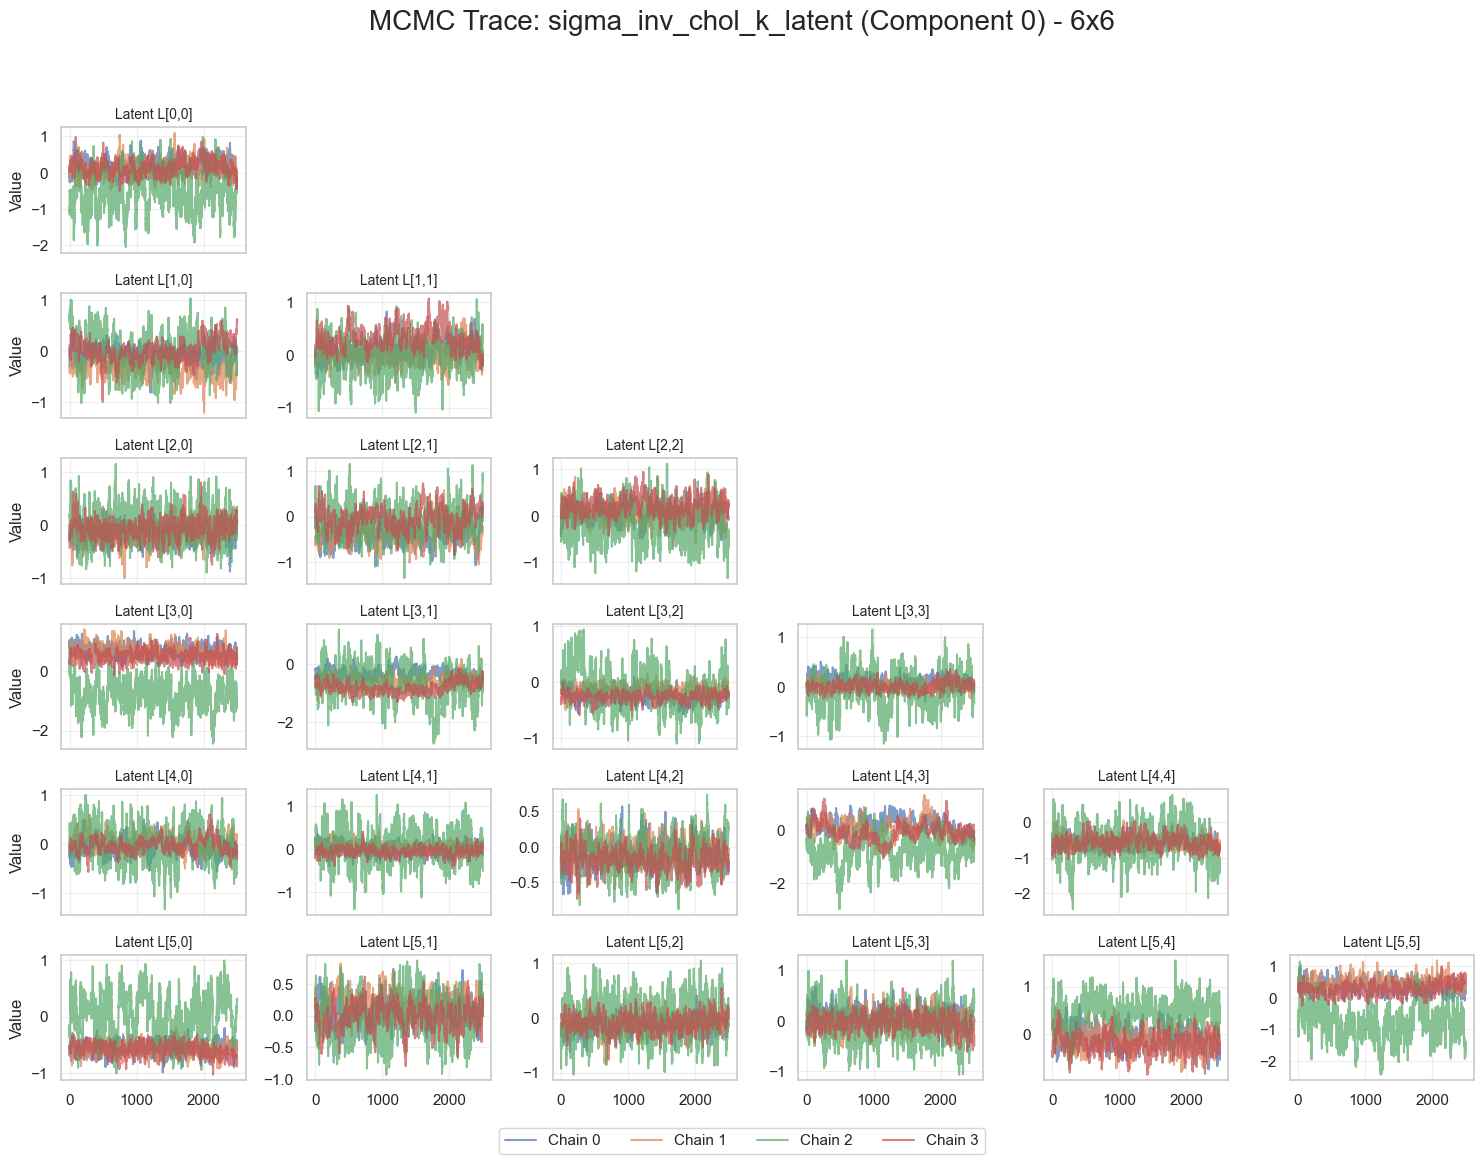

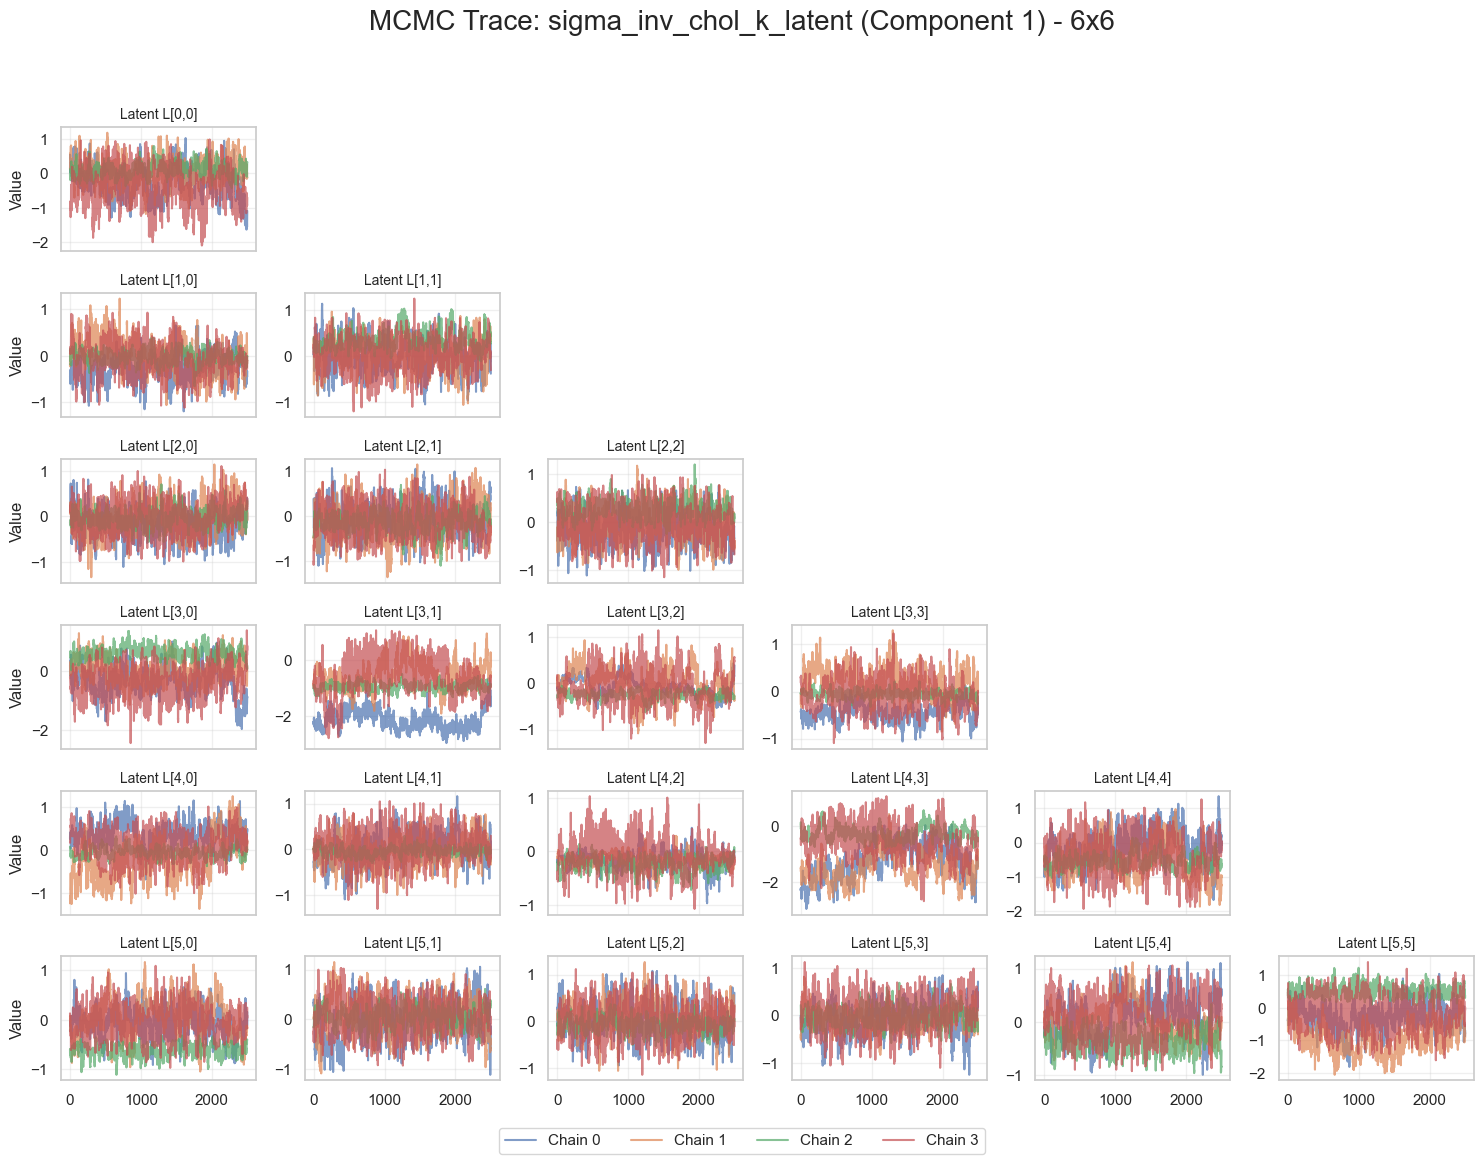


Recovering Covariance Matrices (Sigma_k) from samples...

Plotting Posterior Covariances...


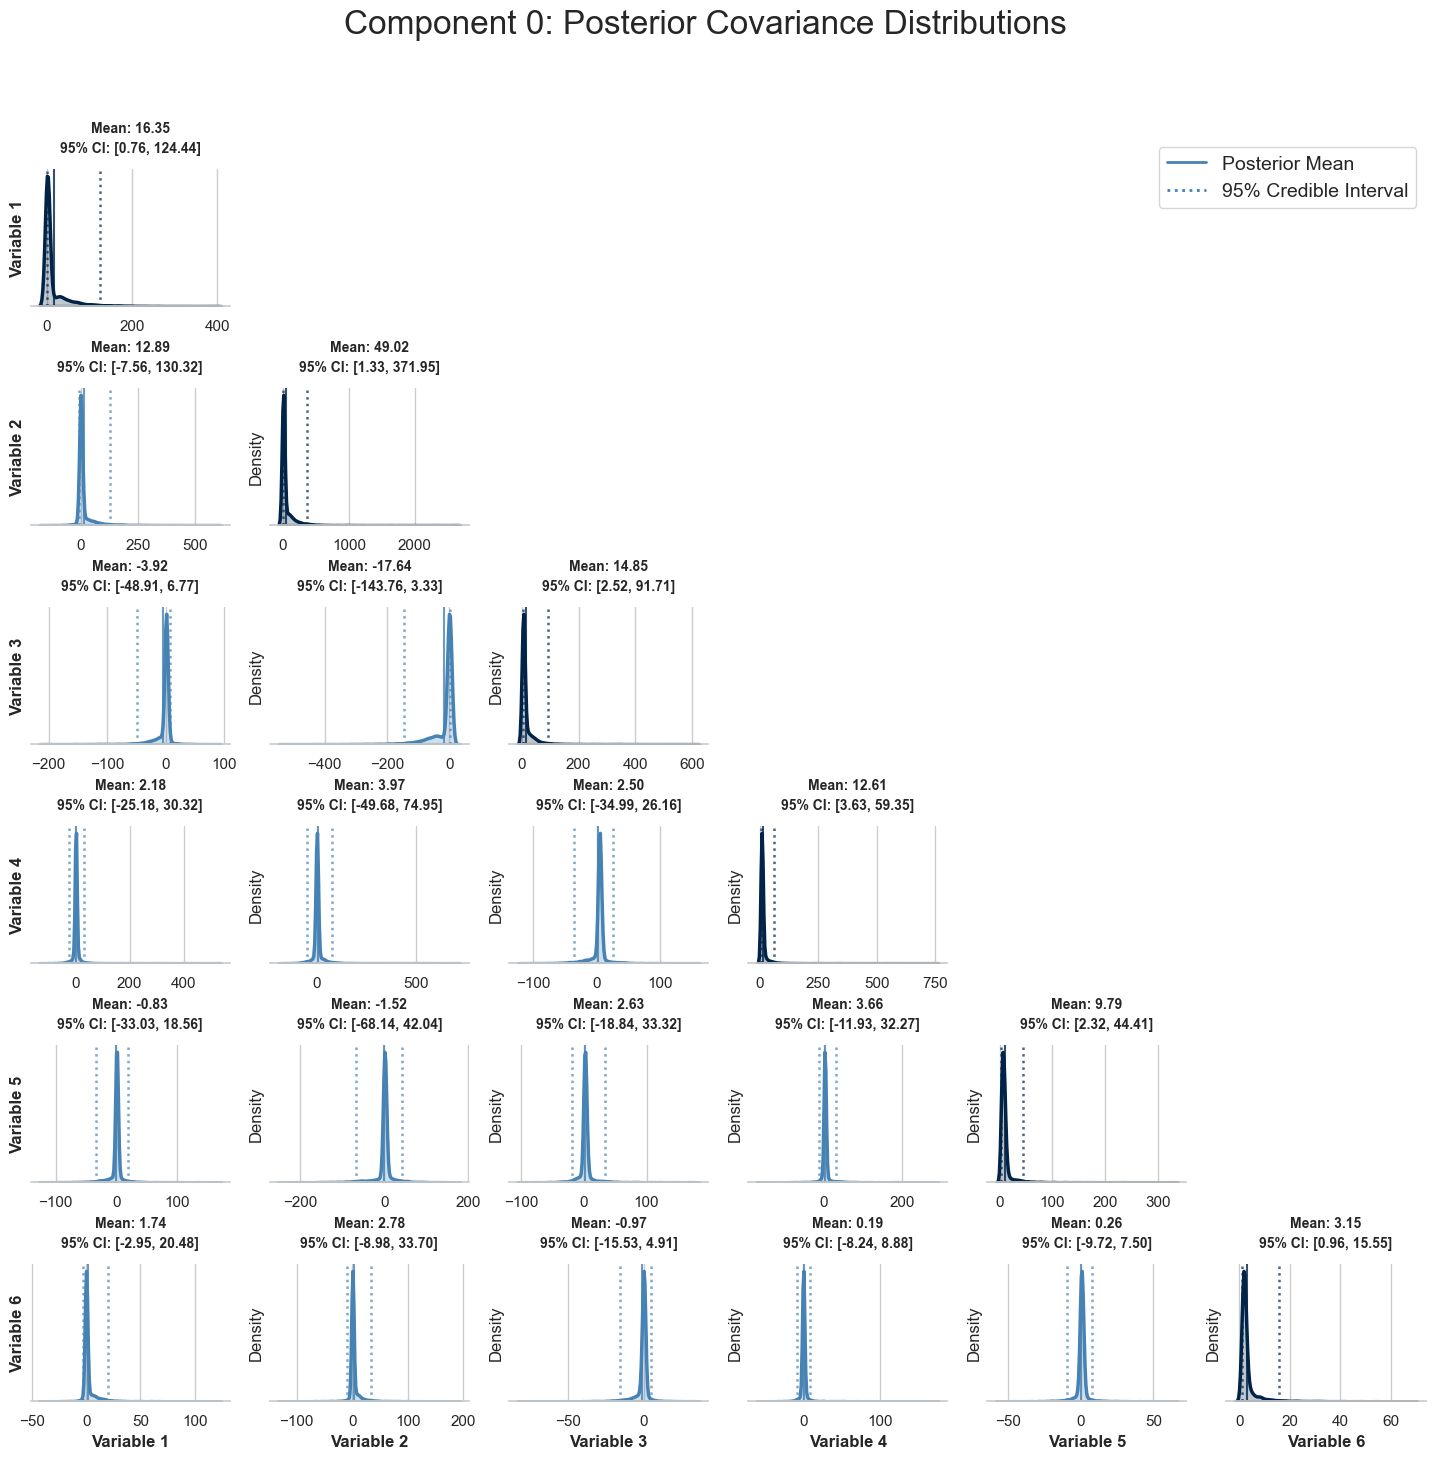

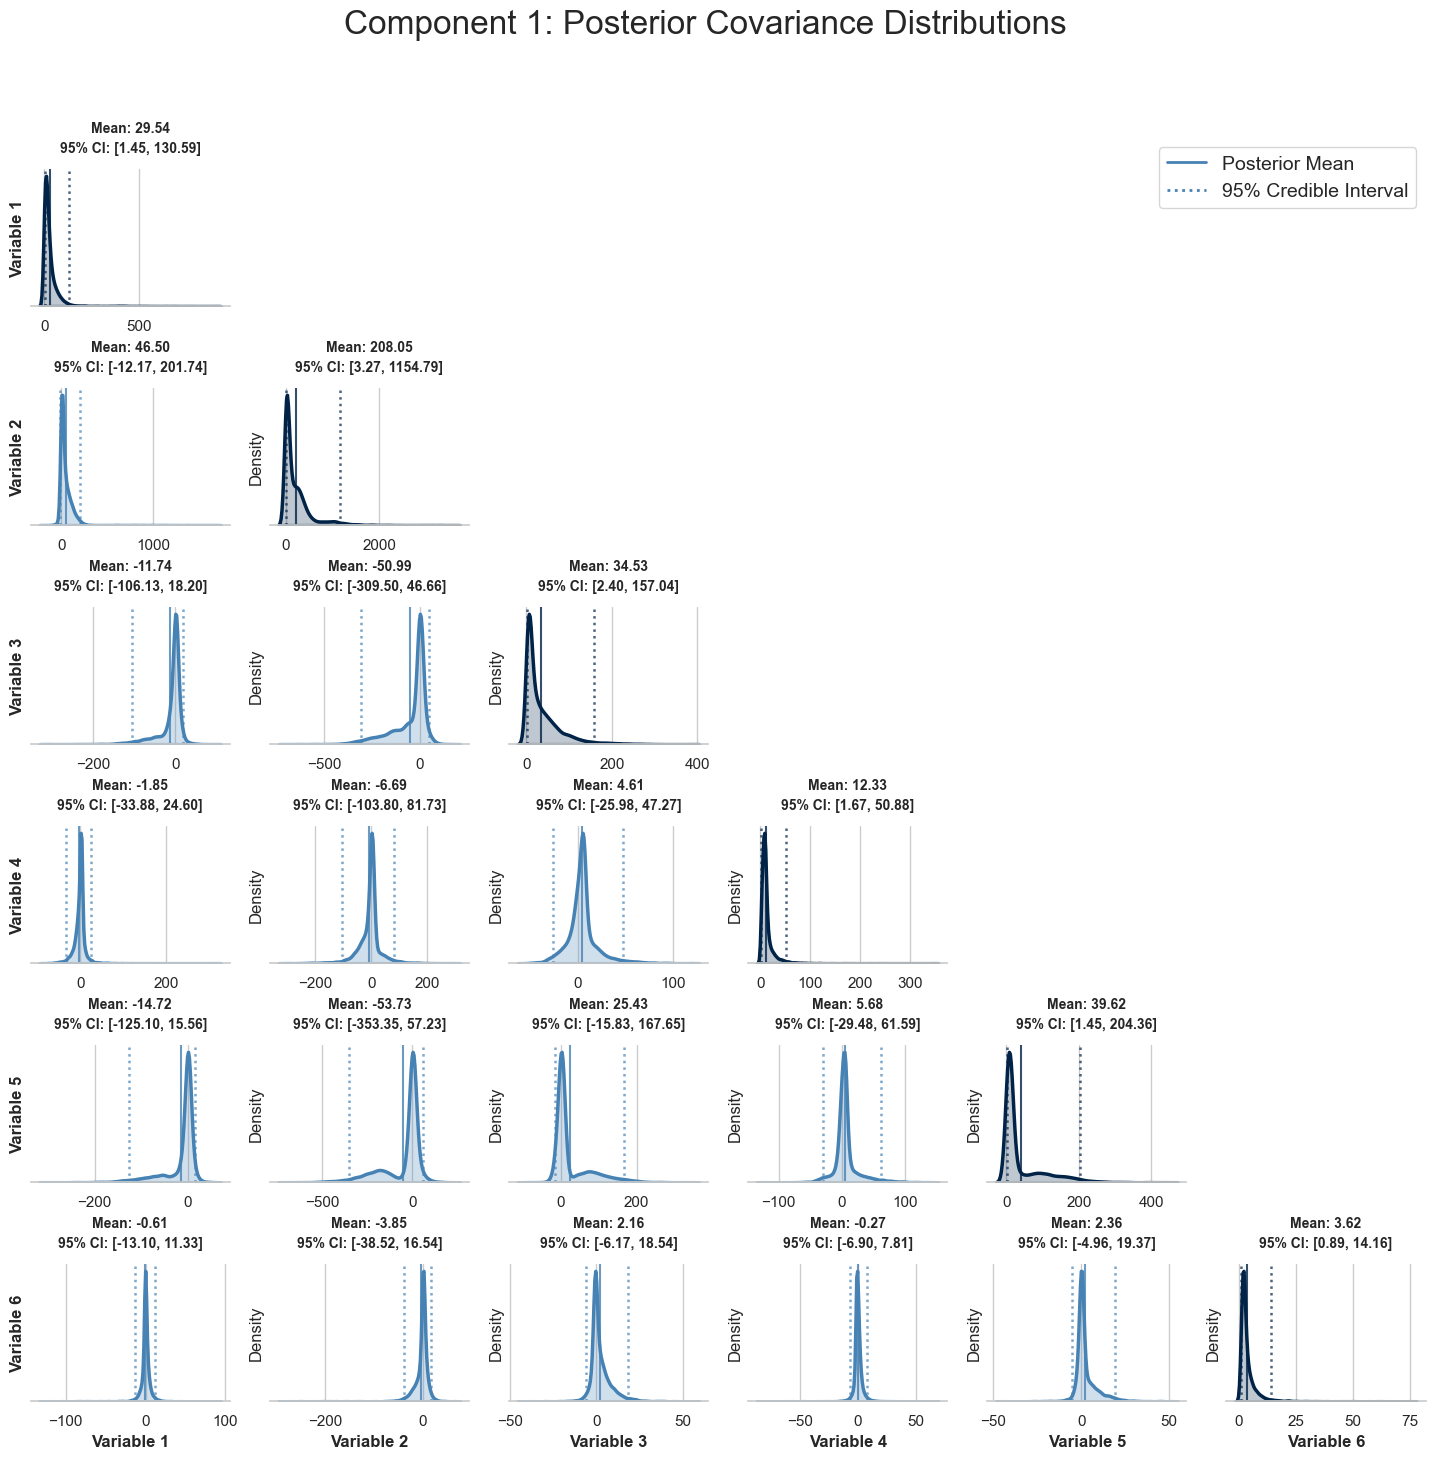

In [7]:
# ── Cell 6 : Diagnostics & Covariance Recovery ────────────────────────────────
print("\n=== MCMC Convergence Summary ===")
# Uncomment the line below to print the full summary (can be quite long)
# summary = gs.Summary(mcmc_results)

def plot_cholesky_traces(samples_dict, n_params, k_idx=0,
                         param_name="sigma_inv_chol_k_latent", figsize=(15, 12)):
    """Plots trace plots for the latent Cholesky factors."""
    latent_samples = samples_dict[param_name][:, :, k_idx, :]
    n_chains, n_draws, n_latent = latent_samples.shape

    fig, axes = plt.subplots(n_params, n_params, figsize=figsize, sharex=True, sharey=False)
    if n_params == 1:
        axes = np.array([[axes]])

    latent_idx = 0
    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]
            if i >= j and latent_idx < n_latent:
                for chain in range(n_chains):
                    ax.plot(latent_samples[chain, :, latent_idx], label=f"Chain {chain}", alpha=0.7)
                ax.set_title(f"Latent L[{i},{j}]", fontsize=10)
                latent_idx += 1
            else:
                ax.axis('off')

            ax.grid(True, alpha=0.3)
            if j == 0:
                ax.set_ylabel("Value")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=n_chains,
               bbox_to_anchor=(0.5, 0.02))
    plt.suptitle(
        f"MCMC Trace: {param_name} (Component {k_idx}) - {n_params}x{n_params}",
        fontsize=20
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

# Extract dimensions from the data_dict
K = int(data_dict["K"])
P = int(data_dict["n_params"])

# 1. Plot Traces for each mixture component
print("\nPlotting Cholesky Traces...")
for k in range(K):
    plot_cholesky_traces(posterior_samples, n_params=P, k_idx=k)


# ── Covariance recovery ────────────────────────────────────────────────────────
print("\nRecovering Covariance Matrices (Sigma_k) from samples...")

bijector_tril = tfb.FillScaleTriL()

def latent_to_sigma(latent_vec):
    """FillScaleTriL latent vector -> Sigma (covariance matrix)."""
    L         = bijector_tril.forward(latent_vec)
    precision = L @ L.T
    return jnp.linalg.inv(precision)

# Vectorize across Chains, Draws, and Components
v_latent_to_sigma = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))
latent_samples_raw = posterior_samples["sigma_inv_chol_k_latent"]
sigma_samples_raw  = v_latent_to_sigma(latent_samples_raw)  # Shape: (chains, draws, K, P, P)


def plot_final_covariance_empirical(samples, component_idx=0):
    """Plots the posterior distributions of the recovered covariance matrix."""
    n_dim = samples.shape[-1]
    fig, axes = plt.subplots(n_dim, n_dim, figsize=(18, 16))
    flattened_samples = samples.reshape(-1, n_dim, n_dim)

    diag_color     = "#002347"
    off_diag_color = "#4682B4"

    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            if j > i:
                ax.axis('off')
                continue

            data_vec      = flattened_samples[:, i, j]
            current_color = diag_color if (i == j) else off_diag_color
            post_mean     = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])

            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            ax.axvline(post_mean, color=current_color, linestyle="-",  lw=1.5, alpha=0.8)
            ax.axvline(ci_low,    color=current_color, linestyle=":",  lw=1.8, alpha=0.7)
            ax.axvline(ci_high,   color=current_color, linestyle=":",  lw=1.8, alpha=0.7)

            title_str = f"Mean: {post_mean:.2f}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
            ax.set_title(title_str, fontsize=10, pad=12, linespacing=1.6, fontweight='bold')
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)

            if i == n_dim - 1:
                ax.set_xlabel(f"Variable {j + 1}", fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"Variable {i + 1}", fontsize=12, fontweight='bold')

    legend_elements = [
        Line2D([0], [0], color=off_diag_color, linestyle='-',  lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=off_diag_color, linestyle=':',  lw=2, label='95% Credible Interval')
    ]
    fig.legend(handles=legend_elements, loc='upper right',
               bbox_to_anchor=(0.9, 0.9), fontsize=14, frameon=True)
    plt.suptitle(
        f"Component {component_idx}: Posterior Covariance Distributions",
        fontsize=24, y=0.98
    )
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

# 2. Plot Covariance matrices for each component
print("\nPlotting Posterior Covariances...")
for k in range(K):
    plot_final_covariance_empirical(
        samples=sigma_samples_raw[:, :, k, :, :],
        component_idx=k
    )

In [9]:
# Define metadata for labeling
D = int(data_dict["n_z"])
P = int(data_dict["n_params"])
K = int(data_dict["K"])



=== Detailed Delta Parameter Diagnostics (Goose Style) ===


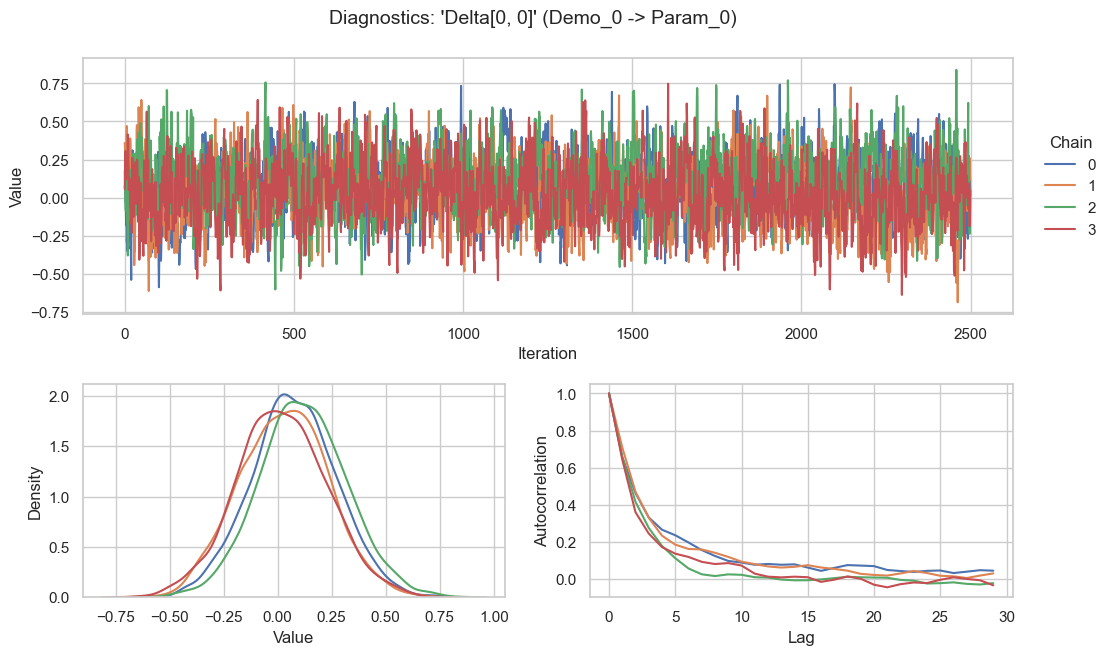

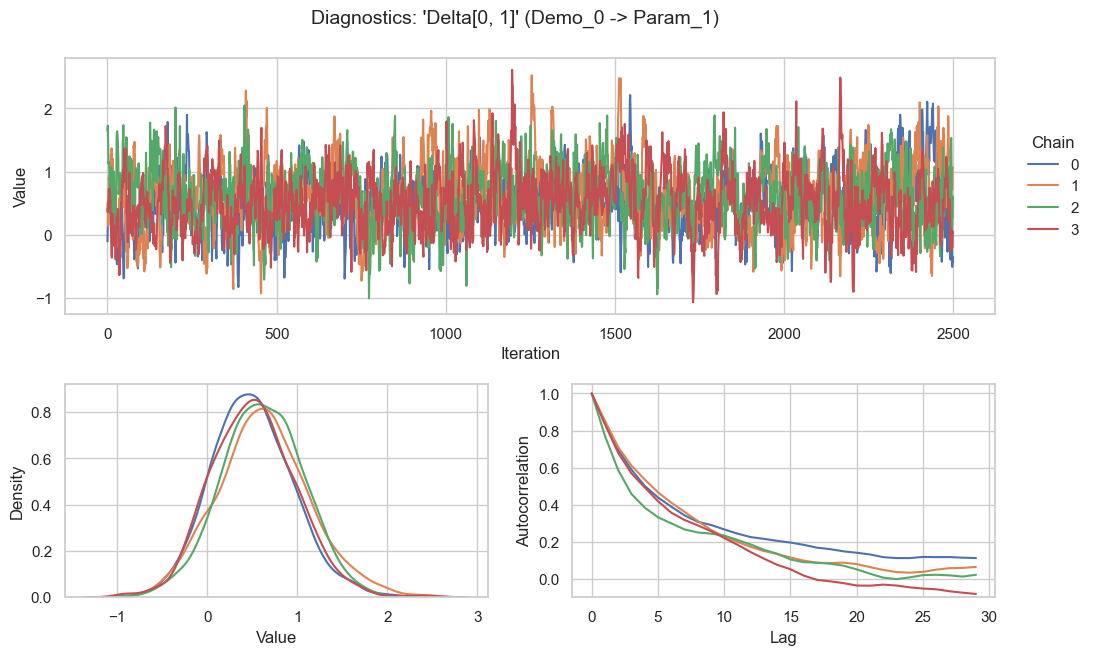

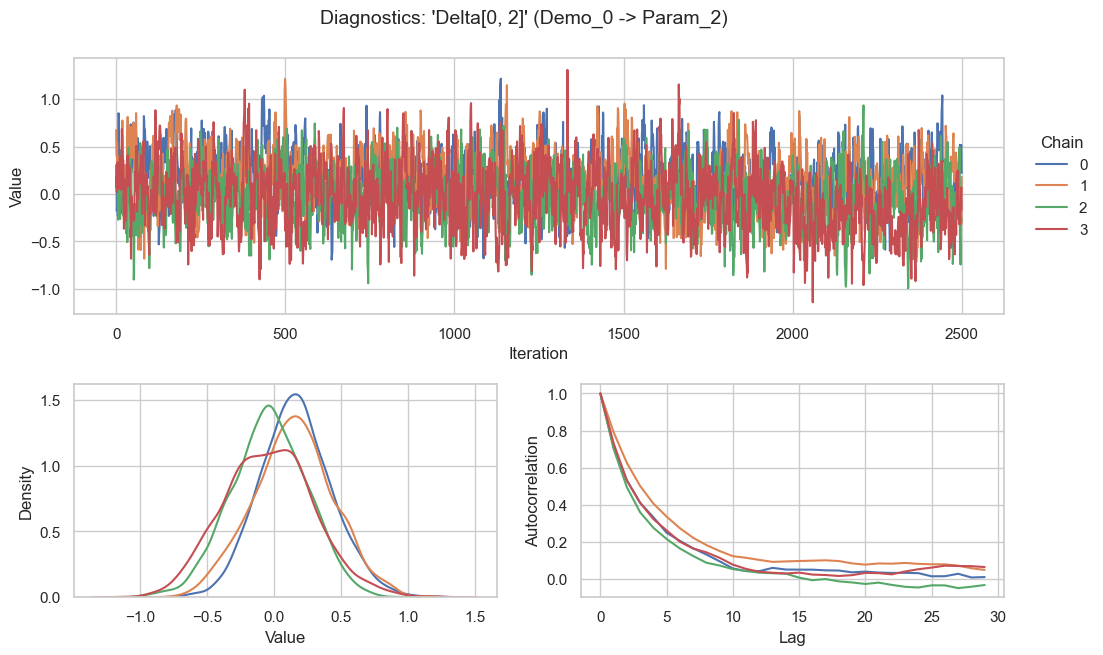

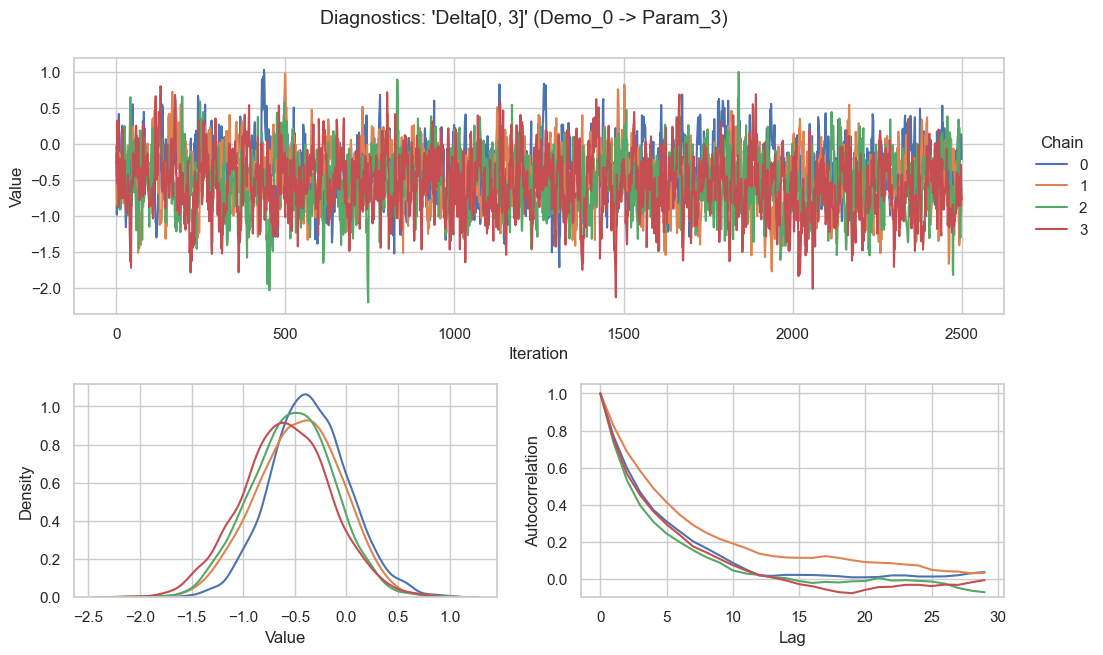

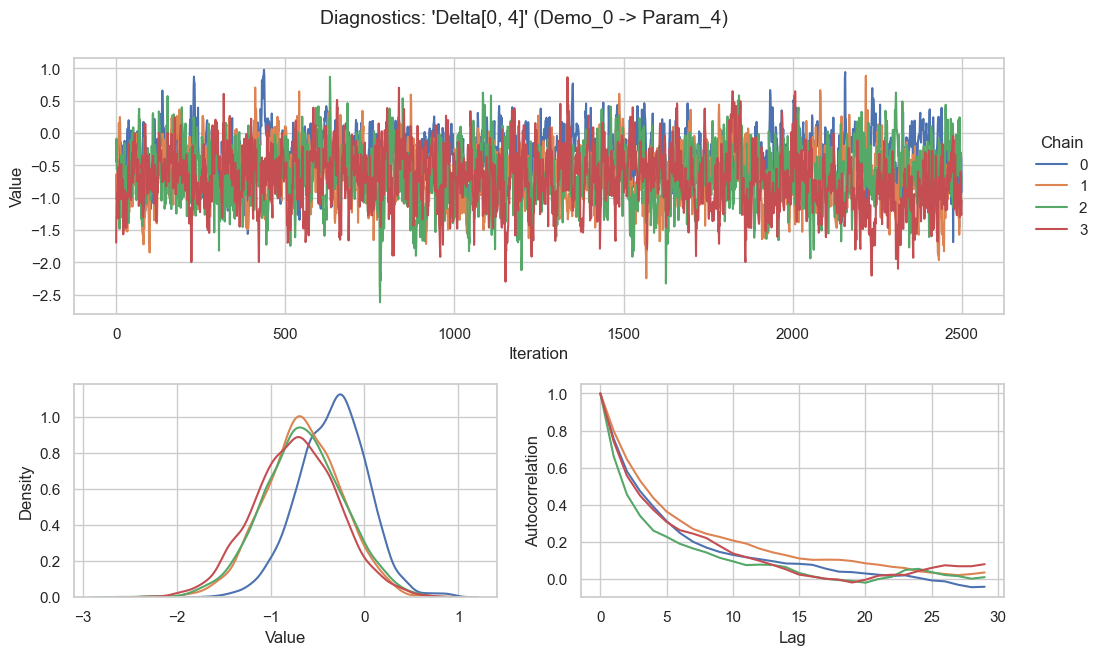

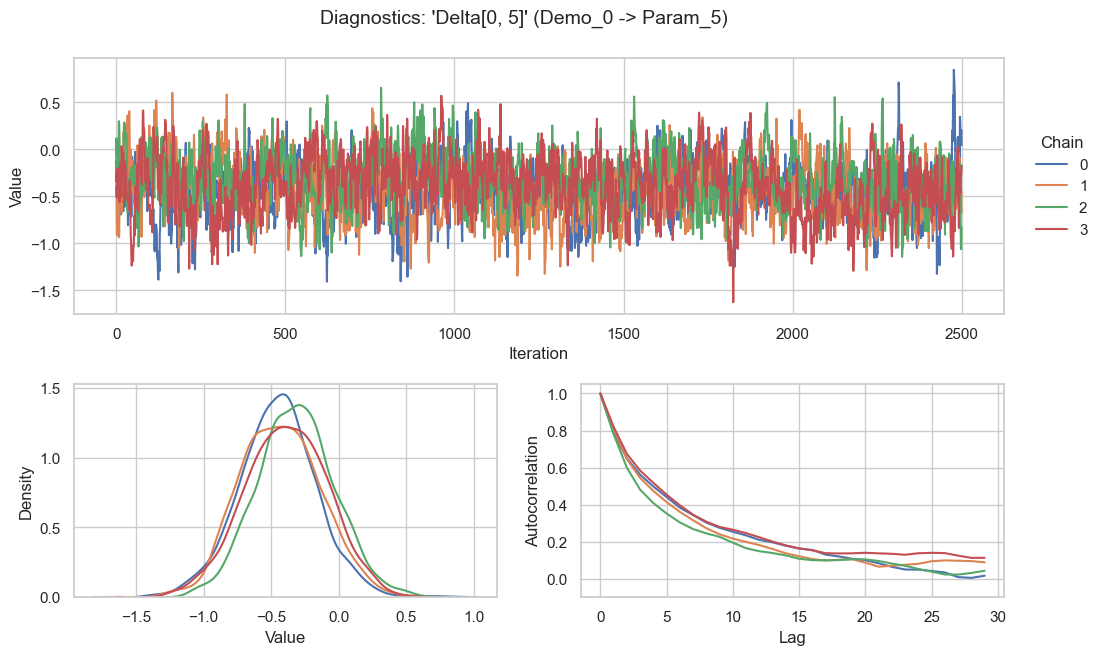

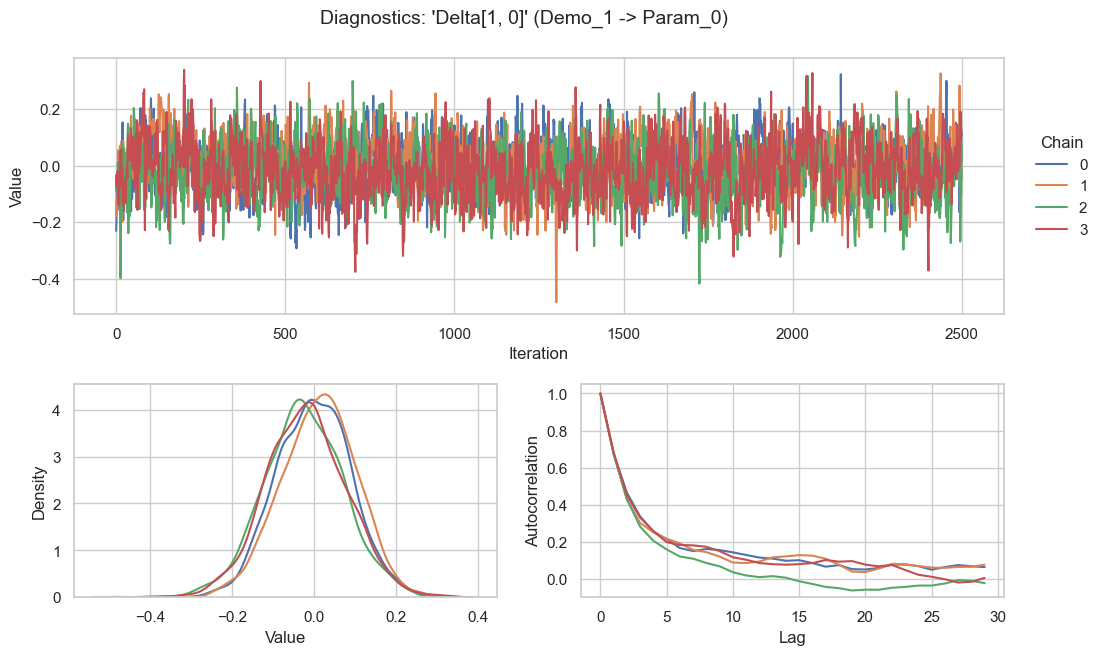

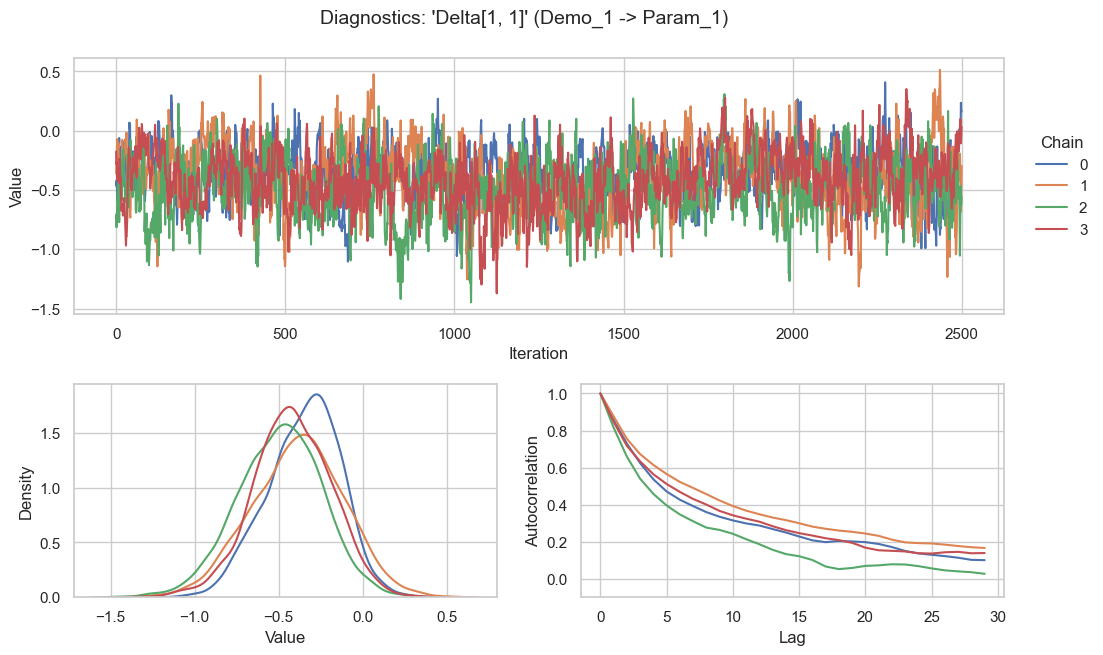

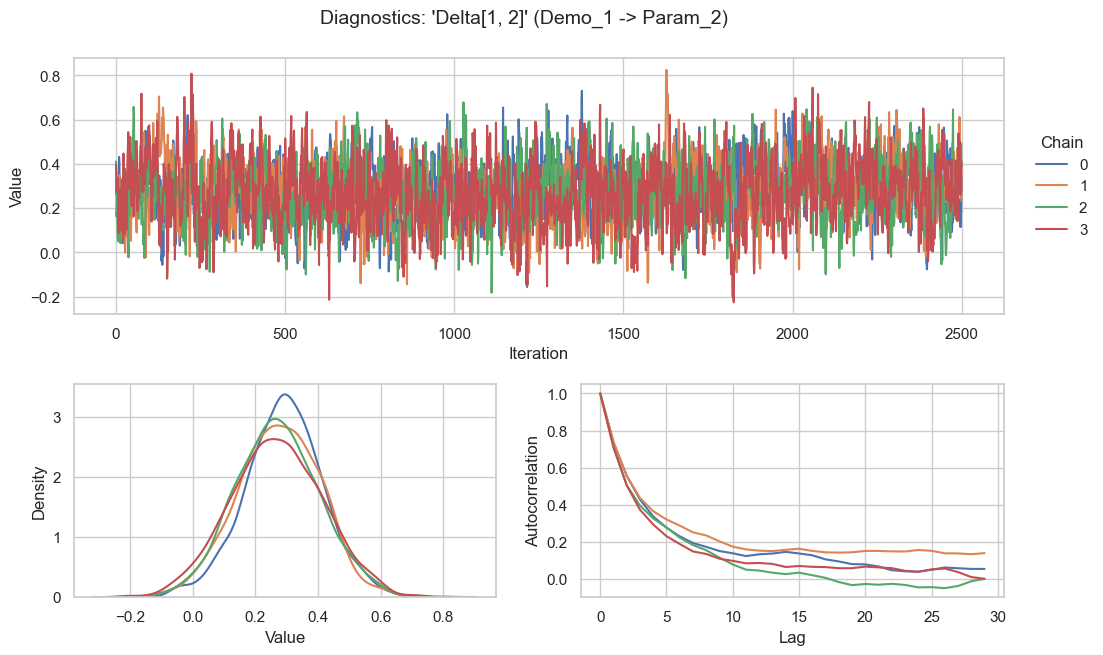

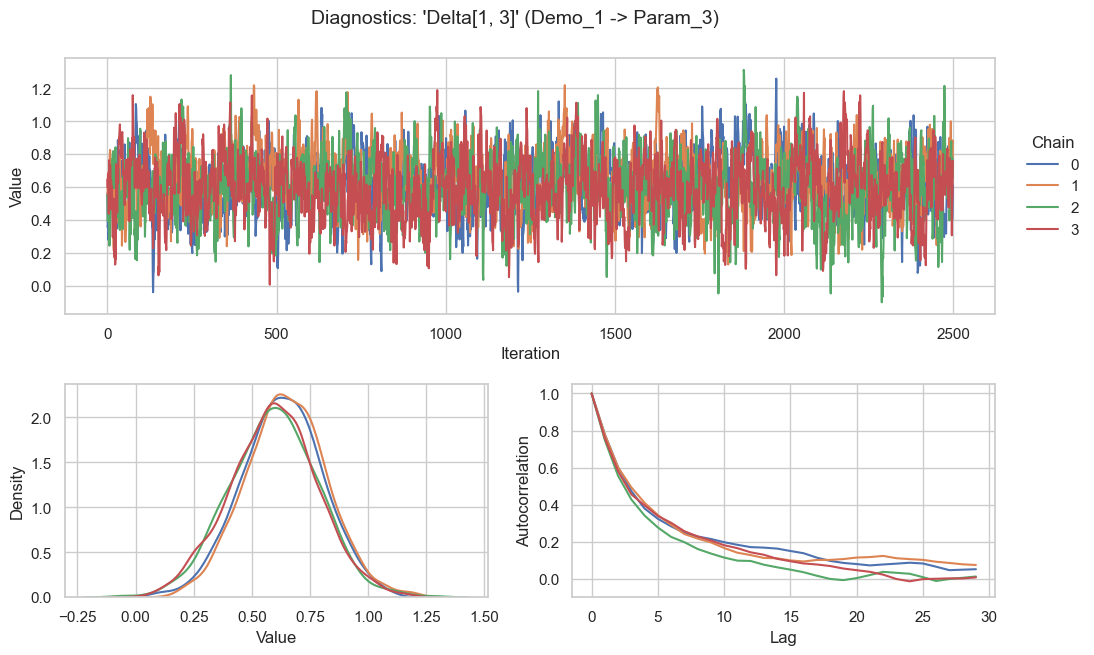

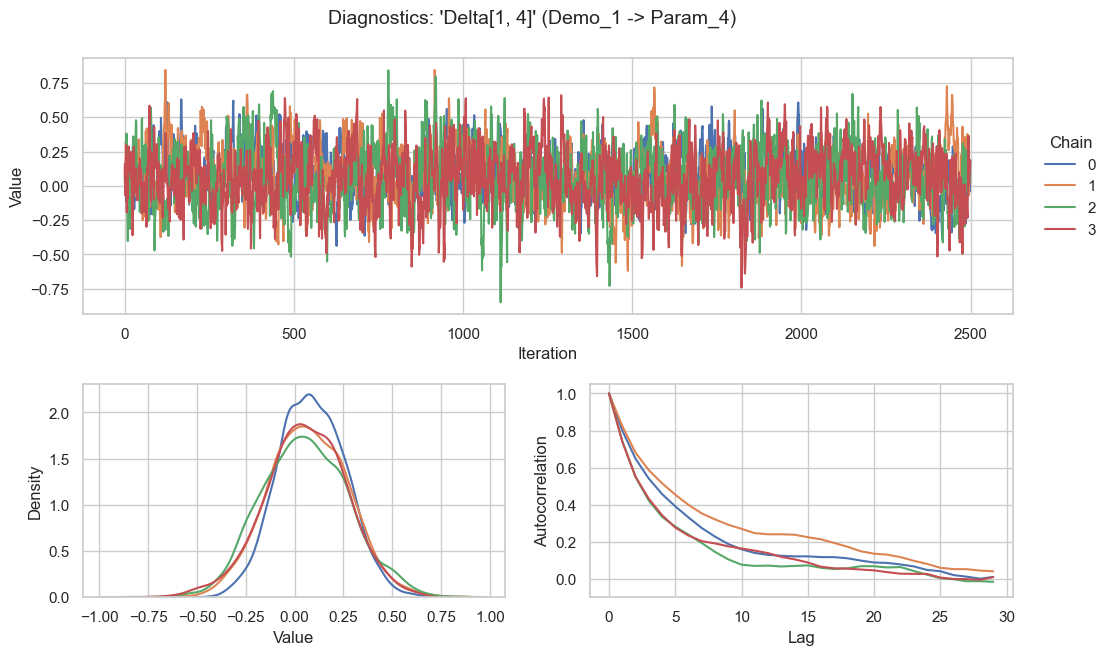

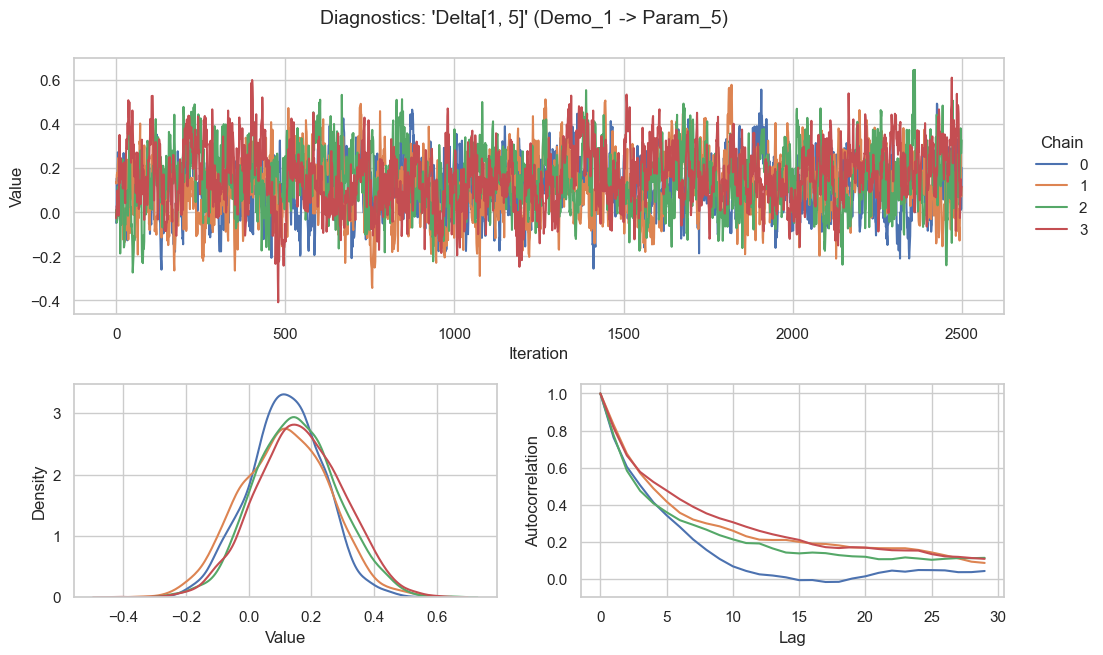

In [10]:
# ── Goose-style chain diagnostics ──────────────────────────────────────────────

def compute_acf(x, nlags=30):
    x_centered = x - np.mean(x)
    norm       = np.sum(x_centered ** 2)
    if norm == 0:
        return np.zeros(nlags)
    acf = np.correlate(x_centered, x_centered, mode='full')
    return (acf[acf.size // 2:] / norm)[:nlags]


def plot_goose_style_diagnostics(delta_array, demo_idx, param_idx,
                                 demo_name, param_name, n_lags=30):
    n_chains = delta_array.shape[0]
    fig = plt.figure(figsize=(12, 7))
    fig.suptitle(
        f"Diagnostics: 'Delta[{demo_idx}, {param_idx}]' ({demo_name} -> {param_name})",
        fontsize=14, y=0.95
    )
    gs_layout = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1], hspace=0.3, wspace=0.2)

    ax_trace = fig.add_subplot(gs_layout[0, :])
    for chain in range(n_chains):
        ax_trace.plot(delta_array[chain, :, demo_idx, param_idx], label=f"{chain}")
    ax_trace.set_xlabel("Iteration")
    ax_trace.set_ylabel("Value")
    ax_trace.grid(True, alpha=1)
    ax_trace.legend(title="Chain", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    ax_dens = fig.add_subplot(gs_layout[1, 0])
    for chain in range(n_chains):
        sns.kdeplot(delta_array[chain, :, demo_idx, param_idx], ax=ax_dens, fill=False)
    ax_dens.set_xlabel("Value")
    ax_dens.set_ylabel("Density")
    ax_dens.grid(True)

    ax_acf = fig.add_subplot(gs_layout[1, 1])
    for chain in range(n_chains):
        ax_acf.plot(
            compute_acf(delta_array[chain, :, demo_idx, param_idx], nlags=n_lags), alpha=1
        )
    ax_acf.set_xlabel("Lag")
    ax_acf.set_ylabel("Autocorrelation")
    ax_acf.set_ylim(-0.1, 1.05)
    ax_acf.grid(True)
    plt.show()


print("\n=== Detailed Delta Parameter Diagnostics (Goose Style) ===")
raw_delta_samples = posterior_samples_sorted["Delta"]
for i in range(D):
    for j in range(P):
        plot_goose_style_diagnostics(
            raw_delta_samples, demo_idx=i, param_idx=j,
            demo_name=f"Demo_{i}", param_name=f"Param_{j}"
        )


=== Global Parameters (Baseline Means mu_k) Summary Tables ===

--- Sorted MCMC Component 0 ---


,Posterior_Mean,Posterior_Std
Parameter,,
Blue Bonnet,-0.1456,2.1642
Fleischmanns,0.2924,4.1275
House,-2.7829,2.7195
Generic,-6.1461,4.0497
Shed Spread,-1.8123,2.3755
log(price),-3.6732,1.6884



--- Sorted MCMC Component 1 ---


,Posterior_Mean,Posterior_Std
Parameter,,
Blue Bonnet,-2.1777,2.2739
Fleischmanns,-7.1176,9.6261
House,-7.0471,4.6366
Generic,-12.2301,6.6893
Shed Spread,-7.7142,7.5986
log(price),-3.6670,1.2820



=== Posterior distribution of Delta (mean + std) ===


,Blue Bonnet,Fleischmanns,House,Generic,Shed Spread,log(price)
log(Income),0.06 (0.21),0.57 (0.48),0.06 (0.31),-0.48 (0.41),-0.59 (0.44),-0.40 (0.30)
Family size,-0.01 (0.10),-0.41 (0.25),0.28 (0.14),0.62 (0.18),0.07 (0.20),0.14 (0.13)



Plotting Delta Distributions...


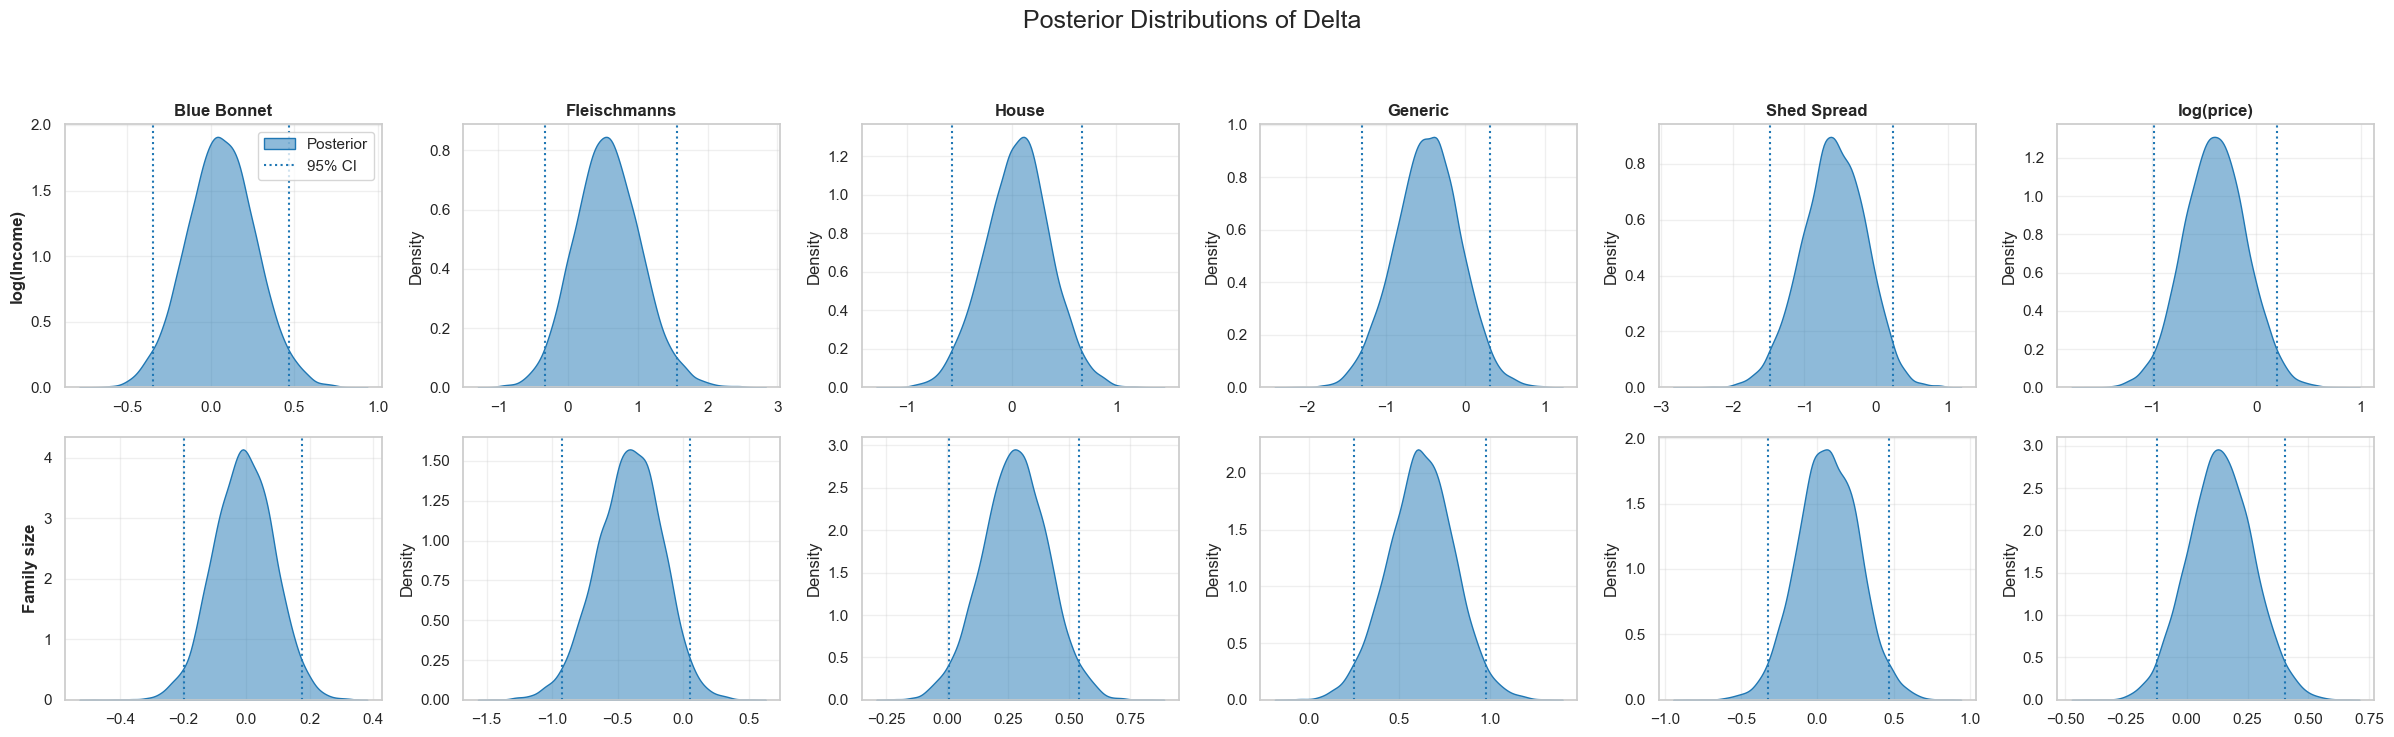

In [ ]:
# ── Cell 7 : Posterior Summaries for mu_k and Delta ───────────────────────────


# Based on your data loading function: 5 intercepts + 1 log price
param_names = ["Blue Bonnet", "Fleischmanns", "House", "Generic", "Shed Spread", "log(price)"]
demo_names = ["log(Income)", "Family size"]

def create_summary_table(post_mu, p_names):
    """Creates a summary dataframe for posterior means and stds."""
    return pd.DataFrame({
        'Parameter':      p_names,
        'Posterior_Mean': post_mu.mean(axis=0),
        'Posterior_Std':  post_mu.std(axis=0)
    }).round(4).set_index("Parameter")

print("\n=== Global Parameters (Baseline Means mu_k) Summary Tables ===")
mu_samples_sorted      = posterior_samples_sorted["mu_k"]
mu_samples_sorted_flat = mu_samples_sorted.reshape(-1, K, P)

# Without ground truth, we simply print the summaries for each MCMC component
for k in range(K):
    print(f"\n--- Sorted MCMC Component {k} ---")
    display(create_summary_table(
        post_mu=mu_samples_sorted_flat[:, k, :],
        p_names=param_names
    ))

# ── Delta Summaries ───────────────────────────────────────────────────────────

def generate_delta_table(delta_draws, p_names, d_names):
    """Formats Delta means and standard deviations into a grid."""
    mean = np.mean(delta_draws, axis=0)
    std  = np.std(delta_draws,  axis=0)
    df   = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{mean[i, j]:.2f} ({std[i, j]:.2f})"
    return df

delta_samples_sorted = posterior_samples_sorted["Delta"].reshape(-1, D, P)

print("\n=== Posterior distribution of Delta (mean + std) ===")
display(generate_delta_table(delta_samples_sorted, param_names, demo_names))

def plot_delta_distributions(delta_samples, p_names, d_names):
    """Plots KDEs for each parameter in the Delta matrix."""
    n_demos, n_params = len(d_names), len(p_names)
    fig, axes = plt.subplots(n_demos, n_params, figsize=(4 * n_params, 3.5 * n_demos))
    
    # Ensure axes is a 2D array even if D=1 or P=1
    if n_demos == 1 and n_params == 1:
        axes = np.array([[axes]])
    elif n_demos == 1:
        axes = axes[None, :]
    elif n_params == 1:
        axes = axes[:, None]

    for d in range(n_demos):
        for p in range(n_params):
            ax      = axes[d, p]
            samples = delta_samples[:, d, p]
            ci_low, ci_high = np.percentile(samples, [2.5, 97.5])

            sns.kdeplot(samples, ax=ax, fill=True, color="#1f77b4", alpha=0.5, label="Posterior")
            ax.axvline(ci_low,  color="#1f77b4", linestyle=":", lw=1.5, label="95% CI")
            ax.axvline(ci_high, color="#1f77b4", linestyle=":", lw=1.5)

            if d == 0:
                ax.set_title(p_names[p], fontweight='bold')
            if p == 0:
                ax.set_ylabel(d_names[d], fontweight='bold')
            ax.grid(True, alpha=0.3)

            # Add legend only to the first subplot to save space
            if d == 0 and p == 0:
                handles, labels = ax.get_legend_handles_labels()
                unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
                ax.legend(*zip(*unique), loc='upper right')

    plt.suptitle("Posterior Distributions of Delta",
                 fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

print("\nPlotting Delta Distributions...")
plot_delta_distributions(delta_samples_sorted, param_names, demo_names)

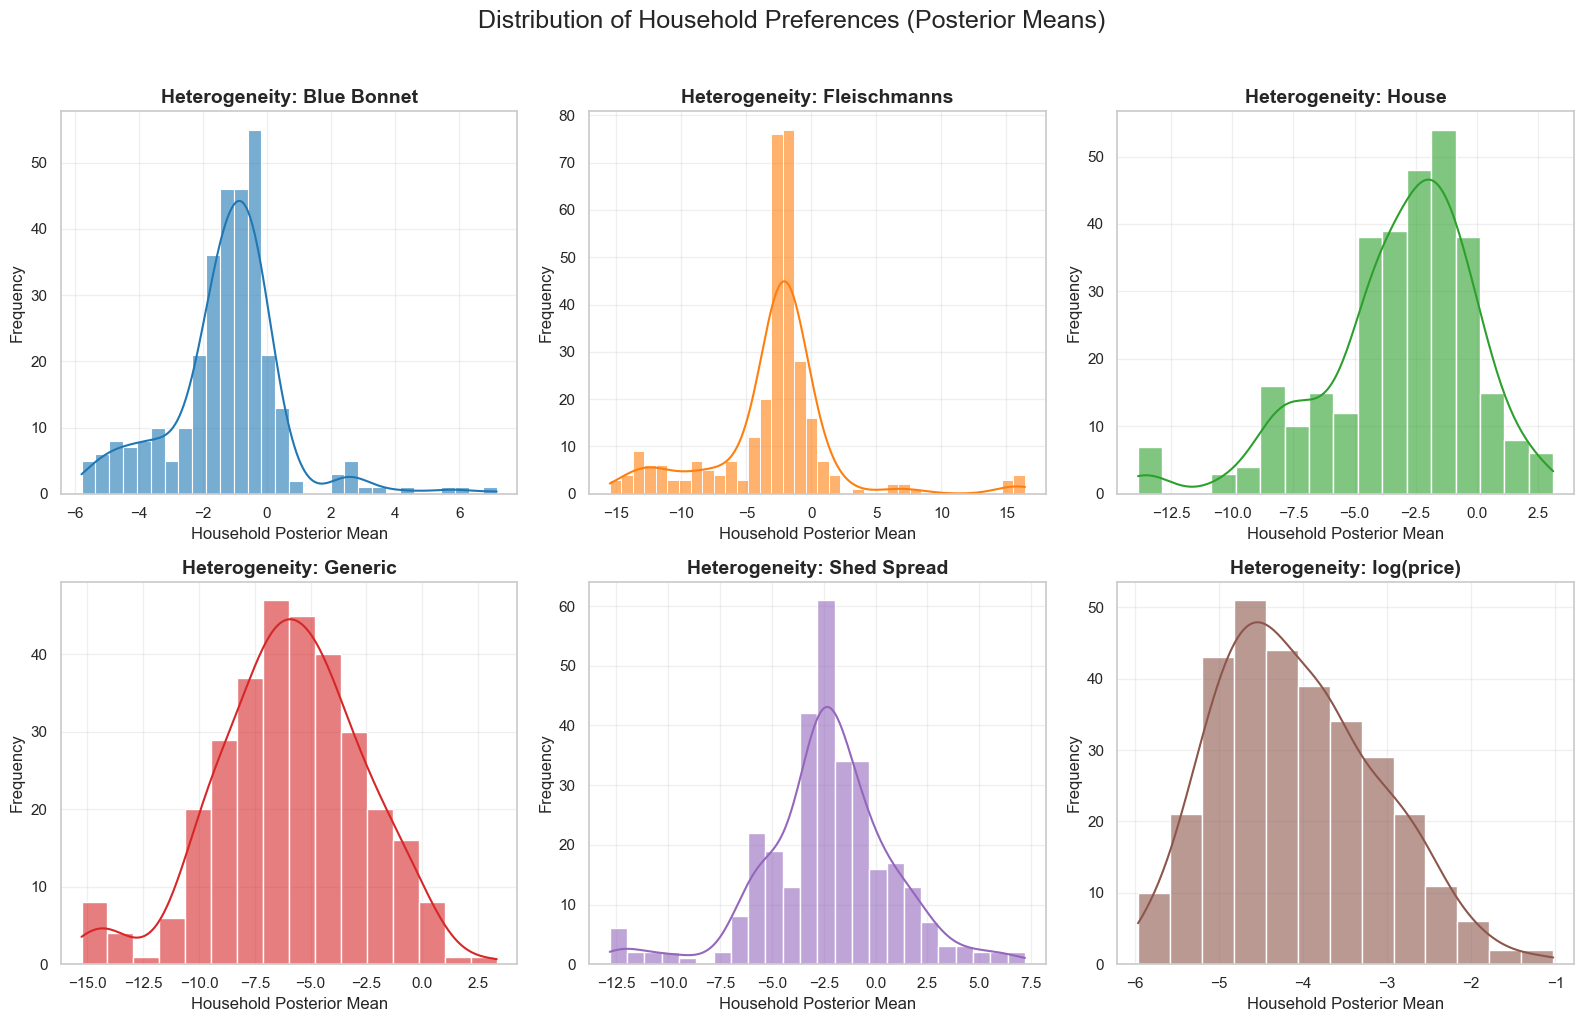


Plotting Household-Level Distributions...


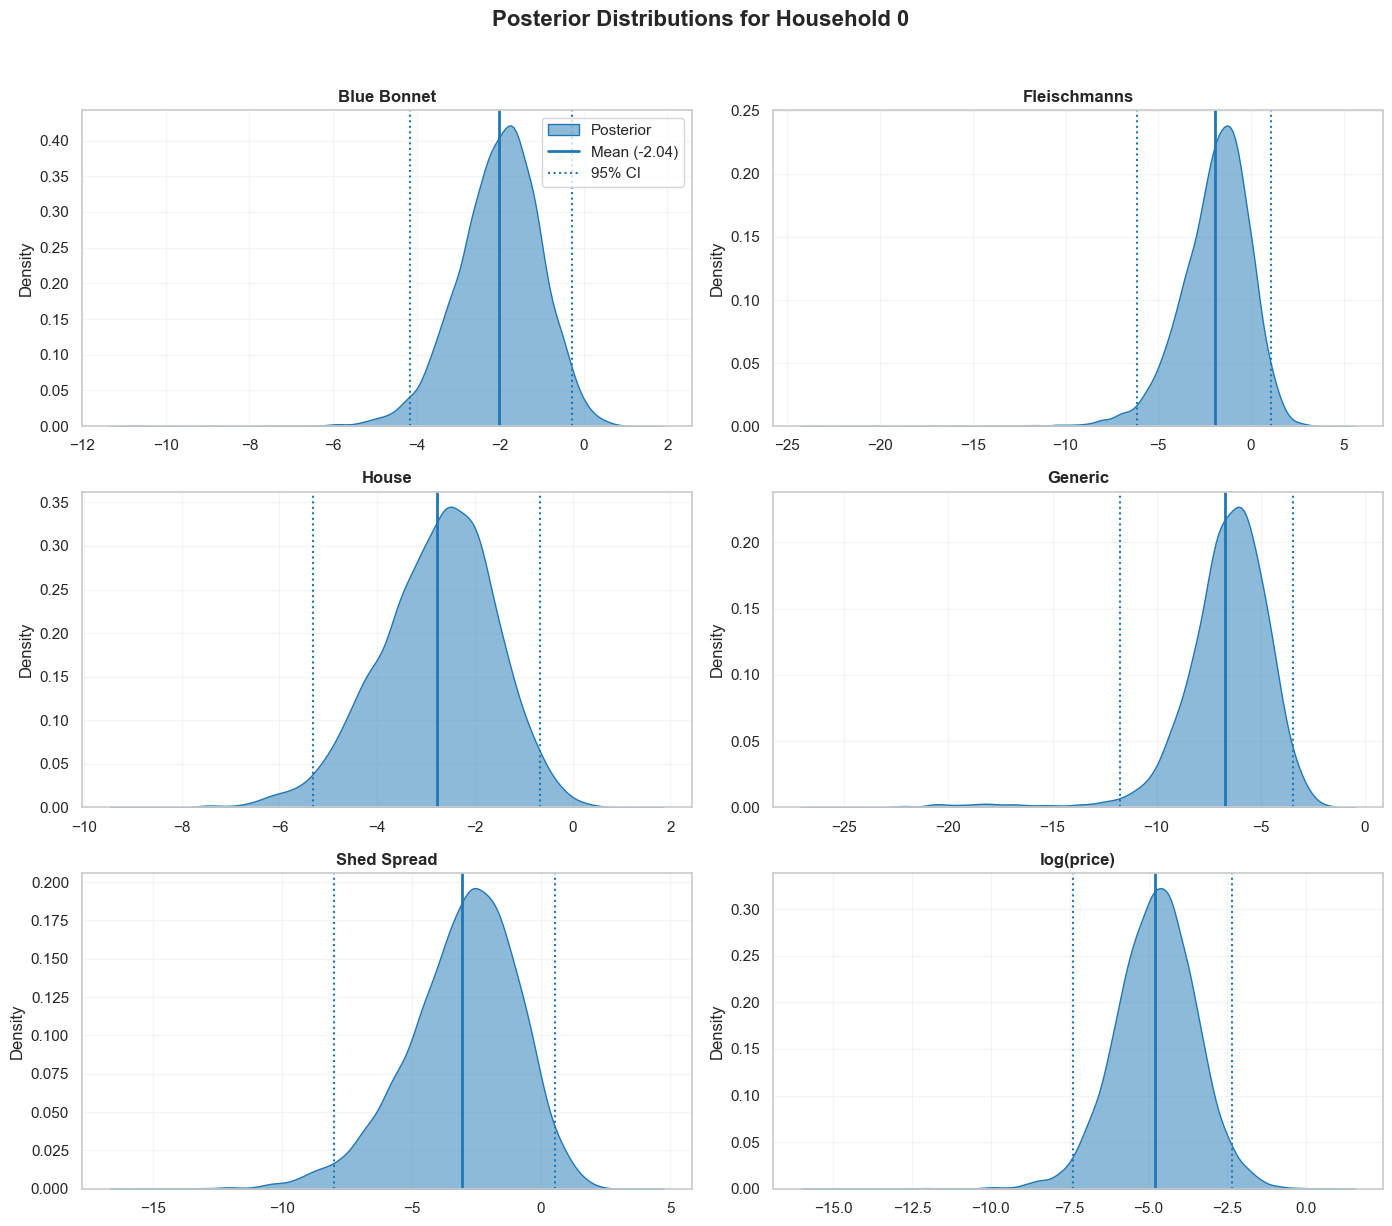

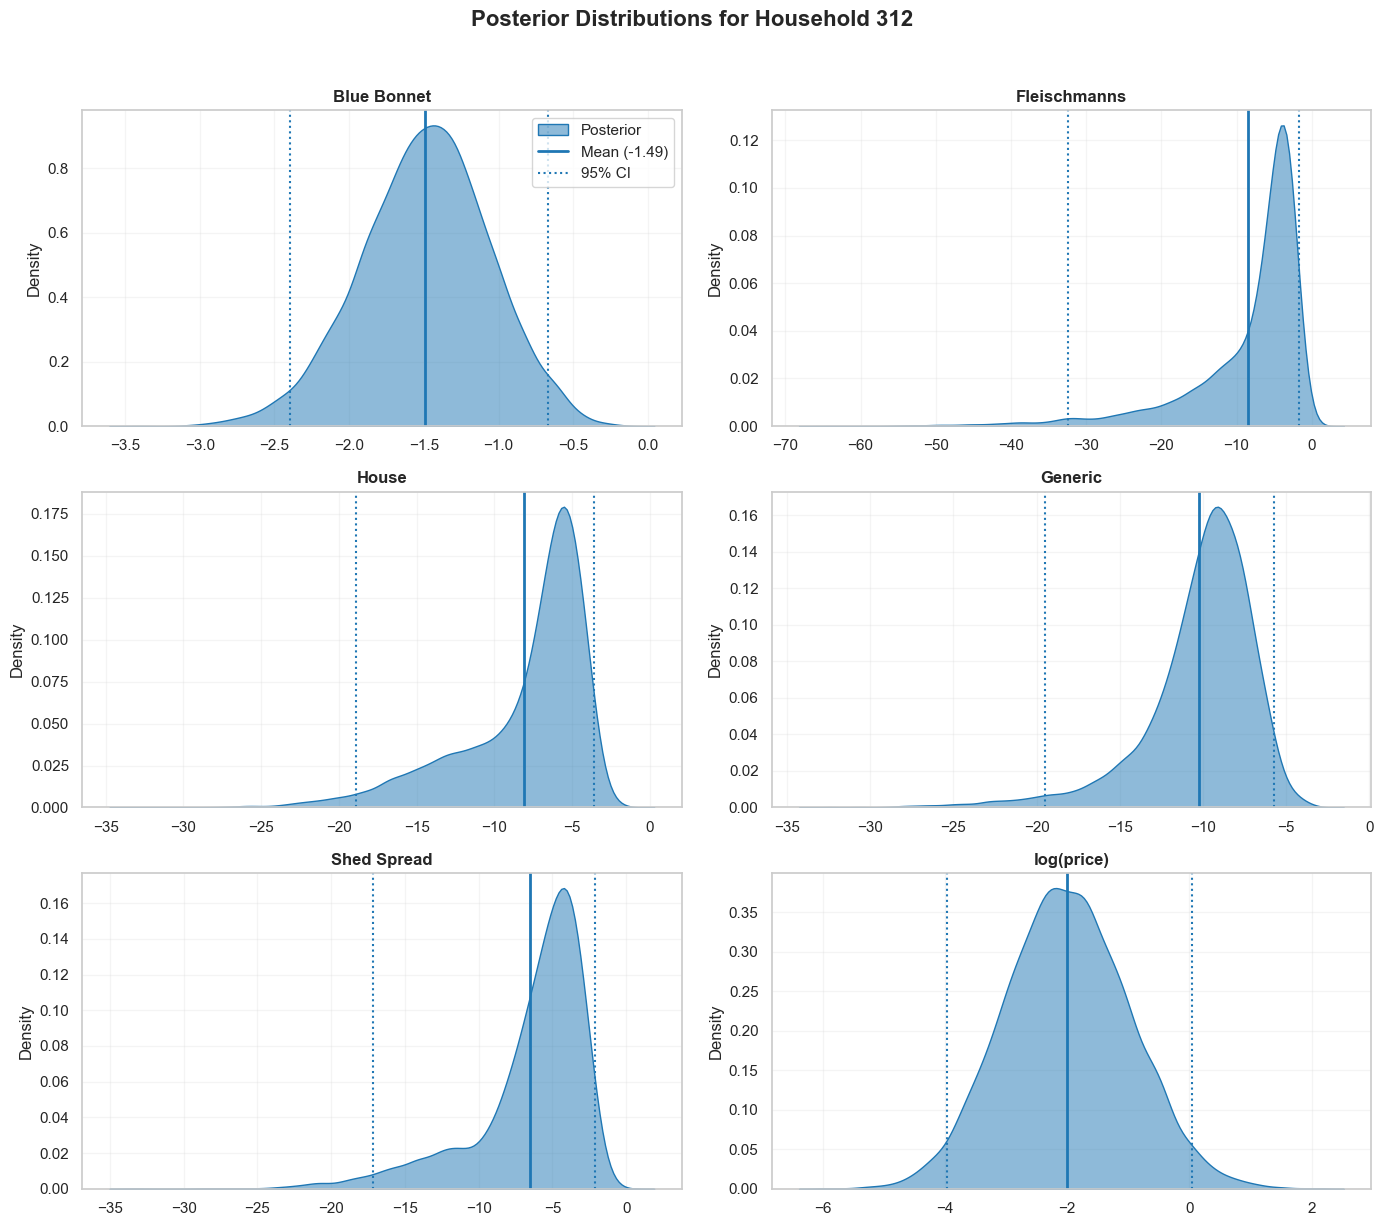

In [ ]:
# ── Cell 8 : Household Heterogeneity (betas) ──────────────────────────────────

n_chains_b, n_draws_b, n_units_b, n_params_b = posterior_samples_sorted["beta_i"].shape
liesel_beta_full = posterior_samples_sorted["beta_i"].reshape(-1, n_units_b, n_params_b)

# Calculate the posterior mean for each household and each parameter
l_beta_means = np.mean(liesel_beta_full, axis=0) # Shape: (n_units, n_params)

# 1. Visualize Population Heterogeneity (Distribution of Household Means)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'][:P]

for i, param in enumerate(param_names):
    ax = axes.flatten()[i]
    sns.histplot(l_beta_means[:, i], kde=True, ax=ax, color=colors[i], alpha=0.6)
    ax.set_title(f"Heterogeneity: {param}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Household Posterior Mean")
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.3)

plt.suptitle("Distribution of Household Preferences (Posterior Means)", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# 2. Visualize Posterior Uncertainty for Specific Households
def plot_beta_distributions(samples, p_names, title_prefix, color_l="#1f77b4"):
    """Plots the posterior distributions for a single unit's beta parameters."""
    cols = 2
    rows = int(np.ceil(len(p_names) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    
    if len(p_names) == 1:
        axes = np.array([axes])

    for i, (ax, param) in enumerate(zip(axes.flatten(), p_names)):
        if i >= len(p_names):
            ax.axis('off')
            continue

        l_vals = samples[:, i]
        ci_low, ci_high = np.percentile(l_vals, [2.5, 97.5])
        post_mean = np.mean(l_vals)

        sns.kdeplot(l_vals, ax=ax, fill=True, color=color_l, alpha=0.5, label="Posterior")
        ax.axvline(post_mean, color=color_l, linestyle="-", lw=2, label=f"Mean ({post_mean:.2f})")
        ax.axvline(ci_low,  color=color_l, linestyle=":", lw=1.5, label="95% CI")
        ax.axvline(ci_high, color=color_l, linestyle=":", lw=1.5)

        ax.set_title(param, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.2)

        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
            unique = [(h, l) for j2, (h, l) in enumerate(zip(handles, labels))
                      if l not in labels[:j2]]
            ax.legend(*zip(*unique), loc="upper right")

    plt.suptitle(title_prefix, y=1.02, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("\nPlotting Household-Level Distributions...")

# Plot uncertainty for the first household
plot_beta_distributions(
    liesel_beta_full[:, 0, :], 
    param_names,
    "Posterior Distributions for Household 0"
)

# Plot uncertainty for the last household
plot_beta_distributions(
    liesel_beta_full[:, -1, :], 
    param_names,
    f"Posterior Distributions for Household {n_units_b - 1}"
)

Posterior mean pvec: [0.63038355 0.36961764]

=== pvec: Posterior Summary ===


,Posterior_Mean,Posterior_Std,CI_2.5%,CI_97.5%
Component,,,,
0,0.6304,0.3257,0.0456,0.9257
1,0.3696,0.3257,0.0743,0.9544



=== pvec: Goose-Style Chain Diagnostics ===


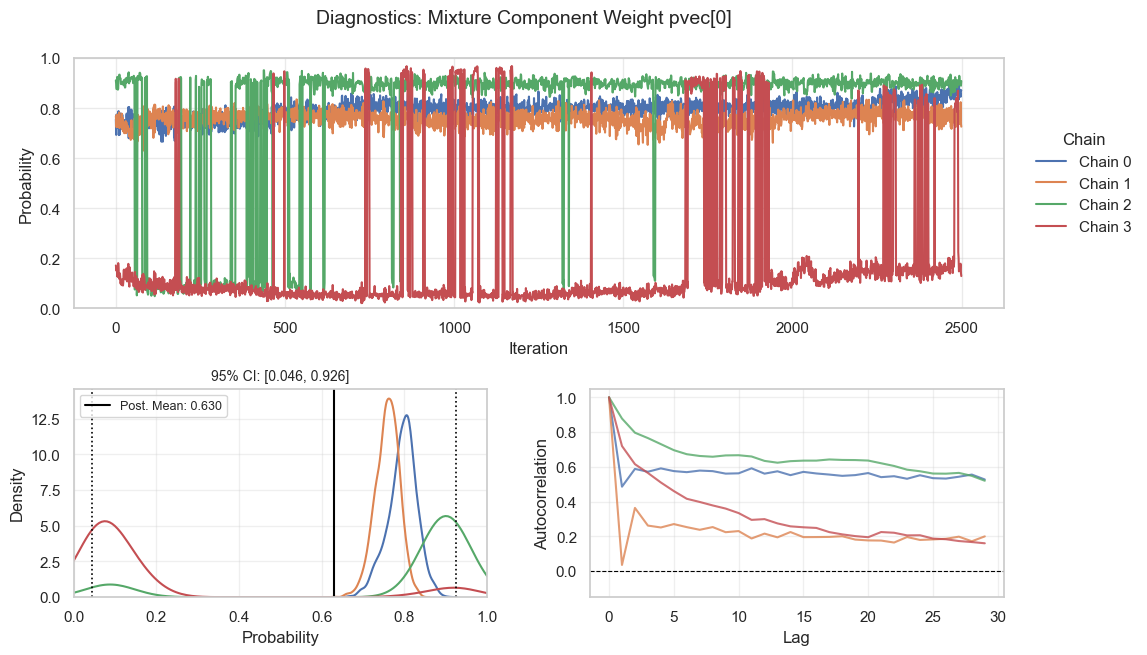

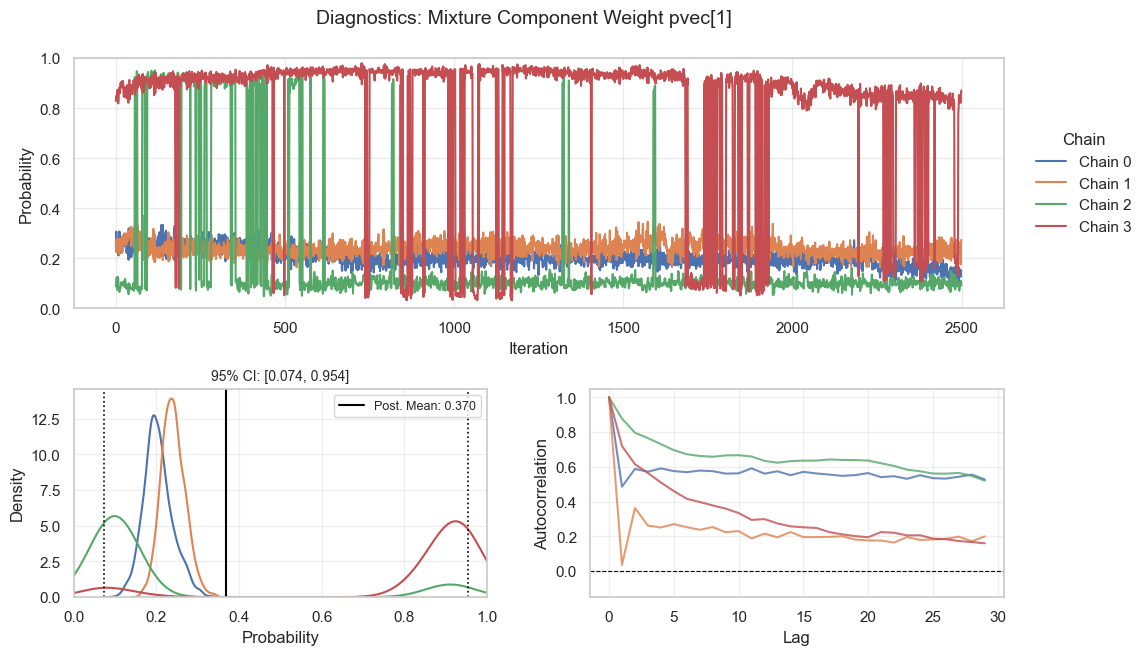

In [ ]:
# ── Cell 9 : pvec diagnostics & posterior summary ─────────────────────────────

flat_pvec = posterior_samples_sorted["pvec"].reshape(-1, K)
print("Posterior mean pvec:", flat_pvec.mean(axis=0))

def plot_pvec_diagnostics(pvec_samples_sorted, K, n_lags=30):
    """Goose-style trace / density / ACF for each mixture weight."""
    n_chains, n_draws, _ = pvec_samples_sorted.shape

    for k in range(K):
        fig = plt.figure(figsize=(12, 7))
        fig.suptitle(f"Diagnostics: Mixture Component Weight pvec[{k}]",
                     fontsize=14, y=0.95)
        gs_layout = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1],
                                      hspace=0.35, wspace=0.25)

        # 1. Trace Plot
        ax_trace = fig.add_subplot(gs_layout[0, :])
        for chain in range(n_chains):
            ax_trace.plot(pvec_samples_sorted[chain, :, k], label=f"Chain {chain}")
        ax_trace.set_xlabel("Iteration")
        ax_trace.set_ylabel("Probability")
        ax_trace.set_ylim(0, 1)
        ax_trace.grid(True, alpha=0.4)
        ax_trace.legend(title="Chain", loc='center left',
                        bbox_to_anchor=(1.02, 0.5), frameon=False)

        # 2. Density Plot
        ax_dens = fig.add_subplot(gs_layout[1, 0])
        all_draws = pvec_samples_sorted[:, :, k].reshape(-1)
        post_mean = all_draws.mean()
        ci_low, ci_high = np.percentile(all_draws, [2.5, 97.5])

        for chain in range(n_chains):
            sns.kdeplot(pvec_samples_sorted[chain, :, k], ax=ax_dens, fill=False)
        ax_dens.axvline(post_mean,    color="black", linestyle="-",  lw=1.5,
                        label=f"Post. Mean: {post_mean:.3f}")
        ax_dens.axvline(ci_low,       color="black", linestyle=":",  lw=1.2)
        ax_dens.axvline(ci_high,      color="black", linestyle=":",  lw=1.2)
        
        ax_dens.set_xlabel("Probability")
        ax_dens.set_ylabel("Density")
        ax_dens.set_xlim(0, 1)
        ax_dens.legend(fontsize=9)
        ax_dens.grid(True, alpha=0.3)
        ax_dens.set_title(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]", fontsize=10)

        # 3. Autocorrelation Plot
        ax_acf = fig.add_subplot(gs_layout[1, 1])
        for chain in range(n_chains):
            ax_acf.plot(
                compute_acf(pvec_samples_sorted[chain, :, k], nlags=n_lags),
                alpha=0.8, label=f"Chain {chain}"
            )
        ax_acf.axhline(0, color="black", lw=0.8, linestyle="--")
        ax_acf.set_xlabel("Lag")
        ax_acf.set_ylabel("Autocorrelation")
        ax_acf.set_ylim(-0.15, 1.05)
        ax_acf.grid(True, alpha=0.3)

        plt.show()


def pvec_summary_table(pvec_samples_sorted, K):
    """Generates a summary DataFrame for the mixture component weights."""
    flat = pvec_samples_sorted.reshape(-1, K)
    rows = []
    for k in range(K):
        draws = flat[:, k]
        ci_low, ci_high = np.percentile(draws, [2.5, 97.5])
        rows.append({
            "Component":      k,
            "Posterior_Mean": draws.mean(),
            "Posterior_Std":  draws.std(),
            "CI_2.5%":        ci_low,
            "CI_97.5%":       ci_high
        })
    return pd.DataFrame(rows).set_index("Component").round(4)


print("\n=== pvec: Posterior Summary ===")
display(pvec_summary_table(
    posterior_samples_sorted["pvec"], K
))

print("\n=== pvec: Goose-Style Chain Diagnostics ===")
plot_pvec_diagnostics(
    posterior_samples_sorted["pvec"], K
)

In [ ]:
# ── Cell 10 : Export Liesel Posterior for Marginal Density Comparison ─────────
#
# This cell extracts and reshapes the posterior samples (mu, std, sigma, pvec)
# and saves them to a .pkl file for downstream analysis or plotting.
# ==============================================================================

import pickle
import pathlib
import numpy as np
import jax
import jax.numpy as jnp
import tensorflow_probability.substrates.jax.bijectors as tfb

# ── Helper ────────────────────────────────────────────────────────────────────
def save_draws_to_pickle(filename, mu_draws, cov_draws, pvec_draws=None):
    """
    Extracts marginal standard deviations and saves mu, std, sigma, pvec to .pkl.
    """
    R, K, nvar = mu_draws.shape

    # Marginal standard deviations from the diagonal of Sigma_k
    std_draws = np.zeros((R, K, nvar))
    for k in range(K):
        for j in range(nvar):
            std_draws[:, k, j] = np.sqrt(np.maximum(cov_draws[:, k, j, j], 0.0))

    if pvec_draws is None:
        pvec_draws = np.ones((R, K))

    data_dict = {
        "mu": mu_draws, 
        "std": std_draws, 
        "pvec": pvec_draws,
        "sigma": cov_draws 
    }

    filepath = pathlib.Path("Data") / filename
    filepath.parent.mkdir(parents=True, exist_ok=True)
    with open(filepath, "wb") as f:
        pickle.dump(data_dict, f)

    print(f"Saved {K}-component empirical draws → {filepath}")
    print(f"  mu    shape : {mu_draws.shape}")
    print(f"  sigma shape : {cov_draws.shape}") 
    print(f"  std   shape : {std_draws.shape}")
    print(f"  pvec  shape : {pvec_draws.shape}")


# ── 1. mu — shape (R, K, P) ───────────────────────────────────────────────────
# posterior_samples_sorted["mu_k"] has shape (n_chains, n_draws, K, P).
# Collapse chains × draws into a single R dimension.
mu_samples_sorted_flat = np.array(
    posterior_samples_sorted["mu_k"]
).reshape(-1, K, P)                                         

# ── 2. Sigma — shape (R, K, P, P) ─────────────────────────────────────────────
# We reconstruct the covariance matrices using the sorted latent variables
# to ensure they match the label-switched means and pvecs.
bijector_tril = tfb.FillScaleTriL()

def latent_to_sigma(latent_vec):
    """FillScaleTriL latent vector → covariance matrix."""
    L = bijector_tril.forward(latent_vec)
    precision = L @ L.T
    return jnp.linalg.inv(precision)

latent_key   = "sigma_inv_chol_k_latent"
latent_draws = posterior_samples_sorted[latent_key]   # (chains, draws, K, latent_dim)
v_lts        = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))
sigma_samples_sorted = v_lts(latent_draws)            # (chains, draws, K, P, P)

sigma_samples_sorted_flat = np.array(sigma_samples_sorted).reshape(-1, K, P, P)  

# ── 3. pvec — shape (R, K) ────────────────────────────────────────────────────
# posterior_samples_sorted["pvec"] was set by resolve_label_switching as
# the permuted simplex values with shape (n_chains, n_draws, K).
flat_pvec = np.array(
    posterior_samples_sorted["pvec"]
).reshape(-1, K)                                            

# ── 4. Sanity checks ──────────────────────────────────────────────────────────
assert mu_samples_sorted_flat.shape == (sigma_samples_sorted_flat.shape[0], K, P), \
    "mu and sigma R-dimension mismatch"
assert flat_pvec.shape[0] == mu_samples_sorted_flat.shape[0], \
    "pvec and mu R-dimension mismatch"
assert np.allclose(flat_pvec.sum(axis=1), 1.0, atol=1e-4), \
    "pvec rows do not sum to 1"

print(f"R (total posterior draws) : {mu_samples_sorted_flat.shape[0]}")
print(f"K (components)            : {K}")
print(f"P (parameters)            : {P}")
print(f"pvec mean per component   : {flat_pvec.mean(axis=0).round(4)}")

# ── 5. Save ───────────────────────────────────────────────────────────────────
# Changed filename to reflect the empirical margarine dataset
save_draws_to_pickle(
    filename=f"margarine_empirical_{K}comp_liesel.pkl",
    mu_draws=mu_samples_sorted_flat,
    cov_draws=sigma_samples_sorted_flat,
    pvec_draws=flat_pvec,
)

R (total posterior draws) : 10000
K (components)            : 2
P (parameters)            : 6
pvec mean per component   : [0.6304 0.3696]
Saved 2-component empirical draws → Data\margarine_empirical_2comp_liesel.pkl
  mu    shape : (10000, 2, 6)
  sigma shape : (10000, 2, 6, 6)
  std   shape : (10000, 2, 6)
  pvec  shape : (10000, 2)
